# Robustness Study: Style Classification Across 5 Splits

# Part 1: Baseline

In [8]:
import os
import json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

import open_clip
from transformers import AutoProcessor, CLIPModel

warnings.filterwarnings("ignore")

# General config
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# OpenFashionCLIP config
OPENFASHIONCLIP_MODEL_NAME = "ViT-B-32"
OPENFASHIONCLIP_PRETRAINED = "laion2b_s34b_b79k"

# FashionCLIP config
FASHIONCLIP_MODEL_ID = "patrickjohncyh/fashion-clip"

# Data root and split folders
DATA_ROOT = Path(os.path.join("..", "..", "1_data", "Style_dataset"))
SPLIT_FOLDERS = [f"style_{i}" for i in range(1, 6)]

def get_split_paths(split_name):
    """Return data paths for a given split folder."""
    split_root = DATA_ROOT / split_name
    return {
        "split_root":    split_root,
        "train_csv":     split_root / "train.csv",
        "val_csv":       split_root / "val.csv",
        "test_csv":      split_root / "test.csv",
        "train_img_dir": split_root / "images" / "train",
        "val_img_dir":   split_root / "images" / "val",
        "test_img_dir":  split_root / "images" / "test",
    }

print("Split folders:", SPLIT_FOLDERS)

Device: cuda
Split folders: ['style_1', 'style_2', 'style_3', 'style_4', 'style_5']


## Dataset Classes

In [9]:
# Generic dataset for ResNet / OpenCLIP
class StyleImageDataset(Dataset):
    def __init__(self, df, image_lookup, label2idx, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.image_lookup = image_lookup
        self.label2idx = label2idx
        self.transform = transform

        keep_rows = []
        missing = 0
        for _, row in self.df.iterrows():
            image_id = str(row["id"])
            if image_id in self.image_lookup:
                keep_rows.append(row)
            else:
                missing += 1

        self.df = pd.DataFrame(keep_rows).reset_index(drop=True)
        print(f"Dataset initialized: {len(self.df)} samples, missing images skipped: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["id"])
        label_name = row["style"]
        label = self.label2idx[label_name]
        image = Image.open(self.image_lookup[image_id]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return {"id": image_id, "image": image, "label": label, "label_name": label_name}


# Raw-image dataset for HuggingFace CLIP processor
class StyleImageRawDataset(Dataset):
    def __init__(self, df, image_lookup, label2idx):
        self.df = df.reset_index(drop=True).copy()
        self.image_lookup = image_lookup
        self.label2idx = label2idx

        keep_rows = []
        missing = 0
        for _, row in self.df.iterrows():
            image_id = str(row["id"])
            if image_id in self.image_lookup:
                keep_rows.append(row)
            else:
                missing += 1

        self.df = pd.DataFrame(keep_rows).reset_index(drop=True)
        print(f"Raw dataset initialized: {len(self.df)} samples, missing images skipped: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["id"])
        label_name = row["style"]
        label = self.label2idx[label_name]
        image = Image.open(self.image_lookup[image_id]).convert("RGB")
        return {"id": image_id, "image": image, "label": label, "label_name": label_name}

## Models and Utilities

In [15]:
# ResNet50 Classifier
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


# OpenFashionCLIP Classifier
class OpenFashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_name, pretrained):
        super().__init__()
        self.backbone = open_clip.create_model(model_name, pretrained=pretrained)

        for p in self.backbone.parameters():
            p.requires_grad = False

        if hasattr(self.backbone.visual, "output_dim"):
            feat_dim = self.backbone.visual.output_dim
        else:
            feat_dim = self.backbone.text_projection.shape[1]

        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        image_features = self.backbone.encode_image(x)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits


# FashionCLIP Classifier
class FashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_id):
        super().__init__()
        self.backbone = CLIPModel.from_pretrained(model_id)

        for p in self.backbone.parameters():
            p.requires_grad = False

        feat_dim = self.backbone.config.projection_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits


# Metrics function
def compute_metrics(y_true, y_pred, label_names):
    acc = accuracy_score(y_true, y_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    per_class_precision, per_class_recall, per_class_f1, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=list(range(len(label_names))),
        average=None, zero_division=0
    )
    per_style_df = pd.DataFrame({
        "style": label_names,
        "precision": per_class_precision,
        "recall": per_class_recall,
        "f1": per_class_f1,
        "support": support
    })
    return {
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "per_style_df": per_style_df
    }


# Train one epoch
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


# Validate one epoch
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, idx2label):
    model.eval()
    running_loss = 0.0
    all_true = []
    all_pred = []
    for batch in tqdm(loader, desc="Validation", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = torch.argmax(logits, dim=1)
        running_loss += loss.item() * labels.size(0)
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
    avg_loss = running_loss / len(loader.dataset)
    label_names = [idx2label[i] for i in range(len(idx2label))]
    metrics = compute_metrics(all_true, all_pred, label_names)
    return avg_loss, metrics


def train_model(model_name, model, train_loader, val_loader, device,
                num_epochs=8, lr=1e-4, weight_decay=1e-4):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_f1 = -1
    history = []

    for epoch in range(1, num_epochs + 1):
        print(f"\n===== {model_name} | Epoch {epoch}/{num_epochs} =====")
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_metrics = validate_one_epoch(model, val_loader, criterion, device, idx2label)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_precision": val_metrics["macro_precision"],
            "val_macro_recall": val_metrics["macro_recall"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)
        print(f"Train loss         : {train_loss:.4f}")
        print(f"Val loss           : {val_loss:.4f}")
        print(f"Val accuracy       : {val_metrics['accuracy']:.4f}")
        print(f"Val macro precision: {val_metrics['macro_precision']:.4f}")
        print(f"Val macro recall   : {val_metrics['macro_recall']:.4f}")
        print(f"Val macro F1       : {val_metrics['macro_f1']:.4f}")
        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            print("Best checkpoint updated.")

    history_df = pd.DataFrame(history)
    history_path = os.path.join(METRIC_DIR, f"{model_name}_history.csv")
    history_df.to_csv(history_path, index=False)
    ckpt_path = os.path.join(CKPT_DIR, f"{model_name}_best.pt")
    torch.save(best_state, ckpt_path)
    print(f"\nSaved history   : {history_path}")
    print(f"Saved checkpoint: {ckpt_path}")

    return {"model_name": model_name, "history_df": history_df,
            "best_ckpt_path": ckpt_path, "best_val_f1": best_val_f1}


@torch.no_grad()
def run_inference(model_name, model, loader, device, idx2label, split_name="test"):
    model.eval()
    all_ids, all_true, all_pred = [], [], []
    for batch in tqdm(loader, desc=f"Inference [{model_name} | {split_name}]", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_ids.extend(batch["id"])
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    pred_df = pd.DataFrame({
        "id": all_ids,
        "true_idx": all_true,
        "pred_idx": all_pred,
        "true_label": [idx2label[x] for x in all_true],
        "pred_label": [idx2label[x] for x in all_pred]
    })
    pred_df["correct"] = (pred_df["true_idx"] == pred_df["pred_idx"]).astype(int)
    pred_path = os.path.join(PRED_DIR, f"{model_name}_{split_name}_predictions.csv")
    pred_df.to_csv(pred_path, index=False)
    print(f"Saved inference results: {pred_path}")
    return pred_df


def evaluate_predictions(pred_df, model_name):
    y_true = pred_df["true_idx"].tolist()
    y_pred = pred_df["pred_idx"].tolist()
    label_names = [idx2label[i] for i in range(len(idx2label))]
    metrics = compute_metrics(y_true, y_pred, label_names)
    per_style_path = os.path.join(METRIC_DIR, f"{model_name}_per_style_metrics.csv")
    metrics["per_style_df"].to_csv(per_style_path, index=False)
    overall_result = {
        "model": model_name,
        "macro_f1": metrics["macro_f1"],
        "accuracy": metrics["accuracy"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"]
    }
    print(f"\n===== Evaluation [{model_name}] =====")
    print(f"Accuracy       : {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall   : {metrics['macro_recall']:.4f}")
    print(f"Macro F1       : {metrics['macro_f1']:.4f}")
    print(f"Saved per-style metrics: {per_style_path}")
    return overall_result, metrics["per_style_df"]


def draw_comparison_figure(overall_df, per_style_compare, save_path):
    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

    ax1 = fig.add_subplot(gs[0])
    ax1.axis("off")
    ax1.set_title("Overall Performance Comparison", fontsize=14, pad=8)

    overall_show = overall_df.copy()
    for col in ["Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]:
        overall_show[col] = overall_show[col].map(lambda x: f"{x:.3f}")

    table1 = ax1.table(
        cellText=overall_show.values,
        colLabels=overall_show.columns,
        cellLoc="center", loc="center"
    )
    table1.auto_set_font_size(False)
    table1.set_fontsize(11)
    table1.scale(1, 1.7)

    ax2 = fig.add_subplot(gs[1])
    ax2.axis("off")
    ax2.set_title("Per-Style Classification Performance (F1 score)", fontsize=13, pad=8)

    bottom_df = per_style_compare.copy().T
    bottom_df.columns = bottom_df.iloc[0]
    bottom_df = bottom_df.iloc[1:].reset_index()
    bottom_df = bottom_df.rename(columns={"index": "Model"})

    style_cols = [c for c in bottom_df.columns if c != "Model"]
    bottom_df["mean"] = bottom_df[style_cols].astype(float).mean(axis=1)

    for col in bottom_df.columns:
        if col != "Model":
            bottom_df[col] = bottom_df[col].map(lambda x: f"{float(x):.3f}")

    table2 = ax2.table(
        cellText=bottom_df.values,
        colLabels=bottom_df.columns,
        cellLoc="center", loc="center"
    )
    table2.auto_set_font_size(False)
    table2.set_fontsize(8.5)
    table2.scale(1, 1.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## Transforms and Preprocessors

In [16]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ResNet50 transforms
resnet_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# OpenCLIP preprocess (initialized once, reused across splits)
openclip_model_tmp, _, openclip_preprocess = open_clip.create_model_and_transforms(
    OPENFASHIONCLIP_MODEL_NAME, pretrained=OPENFASHIONCLIP_PRETRAINED
)
del openclip_model_tmp

# FashionCLIP processor (initialized once, reused across splits)
fashionclip_processor = AutoProcessor.from_pretrained(FASHIONCLIP_MODEL_ID)

def fashionclip_collate_fn(batch):
    images     = [x["image"] for x in batch]
    labels     = torch.tensor([x["label"] for x in batch], dtype=torch.long)
    ids        = [x["id"] for x in batch]
    label_names = [x["label_name"] for x in batch]
    pixel_values = fashionclip_processor(images=images, return_tensors="pt")["pixel_values"]
    return {"id": ids, "image": pixel_values, "label": labels, "label_name": label_names}

print("Transforms and preprocessors initialized.")

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Transforms and preprocessors initialized.


## Training and Evaluation Loop


Baseline | Split: style_1
Train shape: (11784, 2)
Val shape  : (2525, 2)
Test shape : (2526, 2)

Train distribution:
style
street            791
gal               752
mode              737
conservative      732
girlish           729
natural           706
retro             705
Ethnic            700
Formal            700
Casual            700
Sports            700
kireime-casual    692
lolita            684
rock              682
dressy            620
fairy             615
feminine          539
Name: count, dtype: int64

Number of classes: 17
Labels: ['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']

Style label to index mapping:
  Casual -> 0
  Ethnic -> 1
  Formal -> 2
  Sports -> 3
  conservative -> 4
  dressy -> 5
  fairy -> 6
  feminine -> 7
  gal -> 8
  girlish -> 9
  kireime-casual -> 10
  lolita -> 11
  mode -> 12
  natural -> 13
  retro -> 14
  rock -

Training:   0%|          | 0/369 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train loss         : 1.1755
Val loss           : 0.6571
Val accuracy       : 0.7810
Val macro precision: 0.7907
Val macro recall   : 0.7815
Val macro F1       : 0.7810
Best checkpoint updated.

===== ResNet50 | Epoch 2/10 =====


Training:   0%|          | 0/369 [00:00<?, ?it/s]

...

Saved inference results: baseline_result\style_1\predictions\ResNet50_test_predictions.csv


Inference [OpenFashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_1\predictions\OpenFashionCLIP_test_predictions.csv


Inference [FashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_1\predictions\FashionCLIP_test_predictions.csv

===== Evaluation [ResNet50] =====
Accuracy       : 0.7886
Macro Precision: 0.7976
Macro Recall   : 0.7896
Macro F1       : 0.7914
Saved per-style metrics: baseline_result\style_1\metrics\ResNet50_per_style_metrics.csv

===== Evaluation [OpenFashionCLIP] =====
Accuracy       : 0.7300
Macro Precision: 0.7574
Macro Recall   : 0.7267
Macro F1       : 0.7240
Saved per-style metrics: baseline_result\style_1\metrics\OpenFashionCLIP_per_style_metrics.csv

===== Evaluation [FashionCLIP] =====
Accuracy       : 0.7375
Macro Precision: 0.7620
Macro Recall   : 0.7343
Macro F1       : 0.7311
Saved per-style metrics: baseline_result\style_1\metrics\FashionCLIP_per_style_metrics.csv
Saved: baseline_result\style_1\metrics\overall_performance_comparison.csv
             Model  Macro F1  Accuracy  Macro Precision  Macro Recall
0         ResNet50  0.791396  0.788599         0.797606      0.789614
1  OpenFashionC

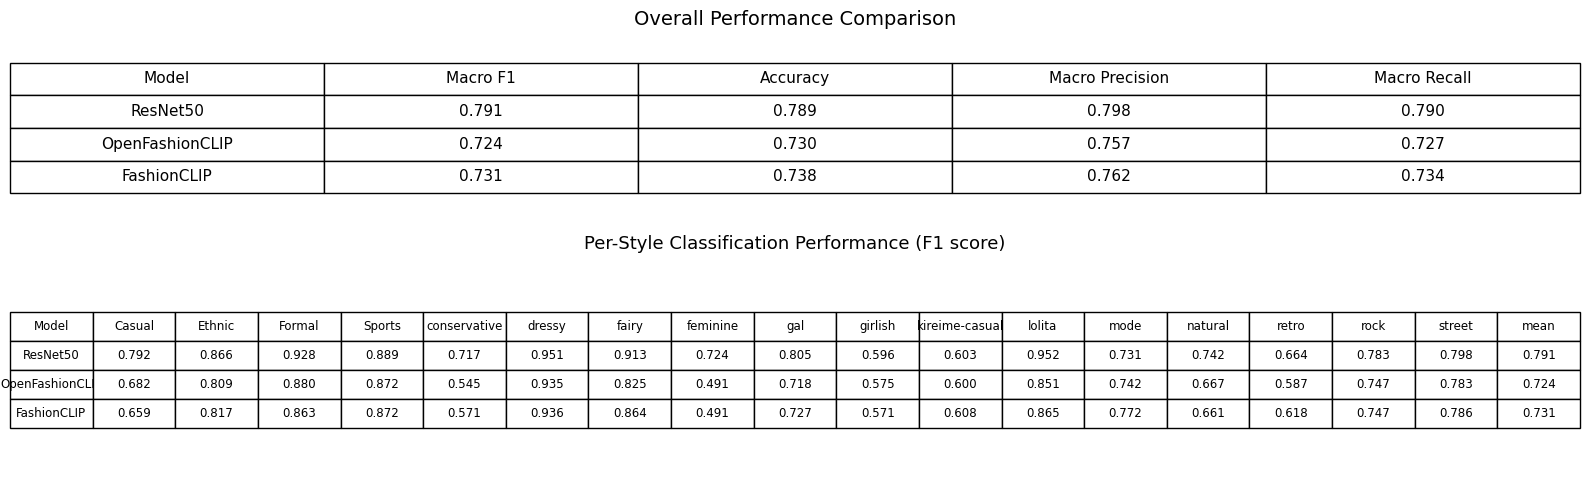

Saved: baseline_result\style_1\figures\baseline_comparison_table.png

Baseline | Split: style_2
Train shape: (11784, 2)
Val shape  : (2525, 2)
Test shape : (2526, 2)

Train distribution:
style
street            791
gal               752
mode              737
conservative      732
girlish           729
retro             706
natural           705
Sports            700
Formal            700
Casual            700
Ethnic            700
kireime-casual    692
lolita            684
rock              682
dressy            620
fairy             615
feminine          539
Name: count, dtype: int64

Number of classes: 17
Labels: ['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']

Style label to index mapping:
  Casual -> 0
  Ethnic -> 1
  Formal -> 2
  Sports -> 3
  conservative -> 4
  dressy -> 5
  fairy -> 6
  feminine -> 7
  gal -> 8
  girlish -> 9
  kireime-casual -> 

Training:   0%|          | 0/369 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train loss         : 1.1799
Val loss           : 0.6702
Val accuracy       : 0.7766
Val macro precision: 0.7831
Val macro recall   : 0.7784
Val macro F1       : 0.7780
Best checkpoint updated.

===== ResNet50 | Epoch 2/10 =====


Training:   0%|          | 0/369 [00:00<?, ?it/s]

...

Saved inference results: baseline_result\style_2\predictions\ResNet50_test_predictions.csv


Inference [OpenFashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_2\predictions\OpenFashionCLIP_test_predictions.csv


Inference [FashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_2\predictions\FashionCLIP_test_predictions.csv

===== Evaluation [ResNet50] =====
Accuracy       : 0.8096
Macro Precision: 0.8137
Macro Recall   : 0.8125
Macro F1       : 0.8109
Saved per-style metrics: baseline_result\style_2\metrics\ResNet50_per_style_metrics.csv

===== Evaluation [OpenFashionCLIP] =====
Accuracy       : 0.7458
Macro Precision: 0.7676
Macro Recall   : 0.7428
Macro F1       : 0.7403
Saved per-style metrics: baseline_result\style_2\metrics\OpenFashionCLIP_per_style_metrics.csv

===== Evaluation [FashionCLIP] =====
Accuracy       : 0.7454
Macro Precision: 0.7687
Macro Recall   : 0.7418
Macro F1       : 0.7394
Saved per-style metrics: baseline_result\style_2\metrics\FashionCLIP_per_style_metrics.csv
Saved: baseline_result\style_2\metrics\overall_performance_comparison.csv
             Model  Macro F1  Accuracy  Macro Precision  Macro Recall
0         ResNet50  0.810930  0.809580         0.813704      0.812491
1  OpenFashionC

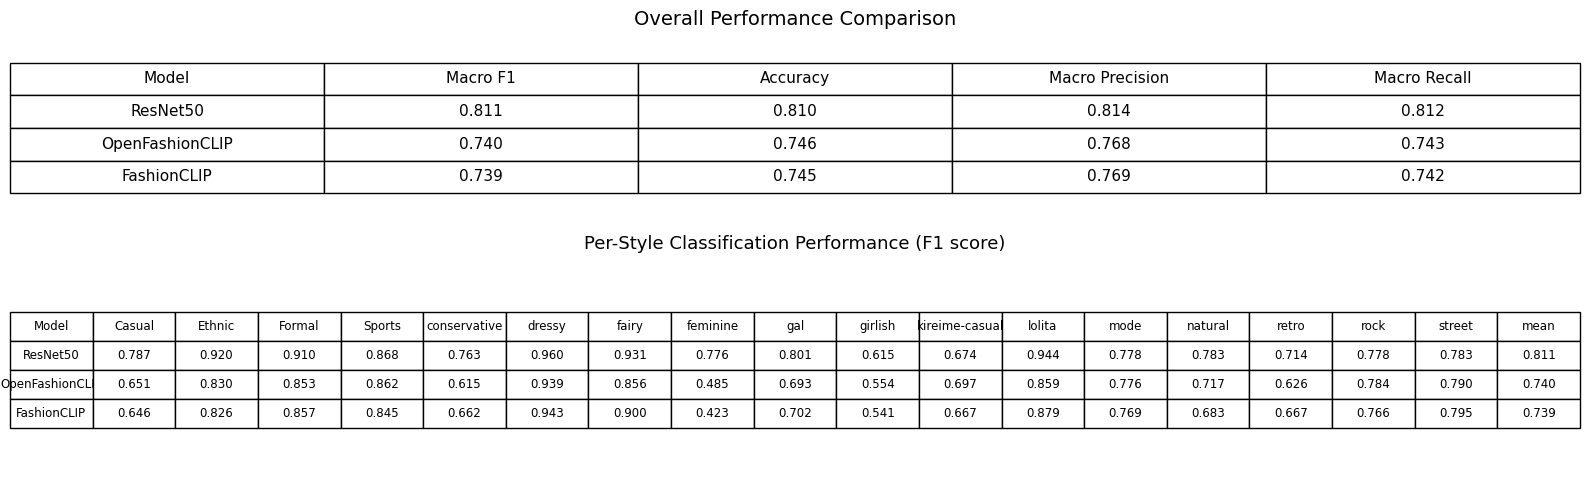

Saved: baseline_result\style_2\figures\baseline_comparison_table.png

Baseline | Split: style_3
Train shape: (11784, 2)
Val shape  : (2525, 2)
Test shape : (2526, 2)

Train distribution:
style
street            791
gal               752
mode              737
conservative      732
girlish           729
natural           706
retro             705
Sports            700
Formal            700
Ethnic            700
Casual            700
kireime-casual    692
lolita            684
rock              682
dressy            620
fairy             615
feminine          539
Name: count, dtype: int64

Number of classes: 17
Labels: ['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']

Style label to index mapping:
  Casual -> 0
  Ethnic -> 1
  Formal -> 2
  Sports -> 3
  conservative -> 4
  dressy -> 5
  fairy -> 6
  feminine -> 7
  gal -> 8
  girlish -> 9
  kireime-casual -> 

Training:   0%|          | 0/369 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train loss         : 1.1654
Val loss           : 0.7435
Val accuracy       : 0.7457
Val macro precision: 0.7642
Val macro recall   : 0.7484
Val macro F1       : 0.7453
Best checkpoint updated.

===== ResNet50 | Epoch 2/10 =====


Training:   0%|          | 0/369 [00:00<?, ?it/s]

...

Saved inference results: baseline_result\style_3\predictions\ResNet50_test_predictions.csv


Inference [OpenFashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_3\predictions\OpenFashionCLIP_test_predictions.csv


Inference [FashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_3\predictions\FashionCLIP_test_predictions.csv

===== Evaluation [ResNet50] =====
Accuracy       : 0.8163
Macro Precision: 0.8198
Macro Recall   : 0.8177
Macro F1       : 0.8172
Saved per-style metrics: baseline_result\style_3\metrics\ResNet50_per_style_metrics.csv

===== Evaluation [OpenFashionCLIP] =====
Accuracy       : 0.7451
Macro Precision: 0.7658
Macro Recall   : 0.7411
Macro F1       : 0.7377
Saved per-style metrics: baseline_result\style_3\metrics\OpenFashionCLIP_per_style_metrics.csv

===== Evaluation [FashionCLIP] =====
Accuracy       : 0.7383
Macro Precision: 0.7573
Macro Recall   : 0.7346
Macro F1       : 0.7318
Saved per-style metrics: baseline_result\style_3\metrics\FashionCLIP_per_style_metrics.csv
Saved: baseline_result\style_3\metrics\overall_performance_comparison.csv
             Model  Macro F1  Accuracy  Macro Precision  Macro Recall
0         ResNet50  0.817159  0.816310         0.819833      0.817714
1  OpenFashionC

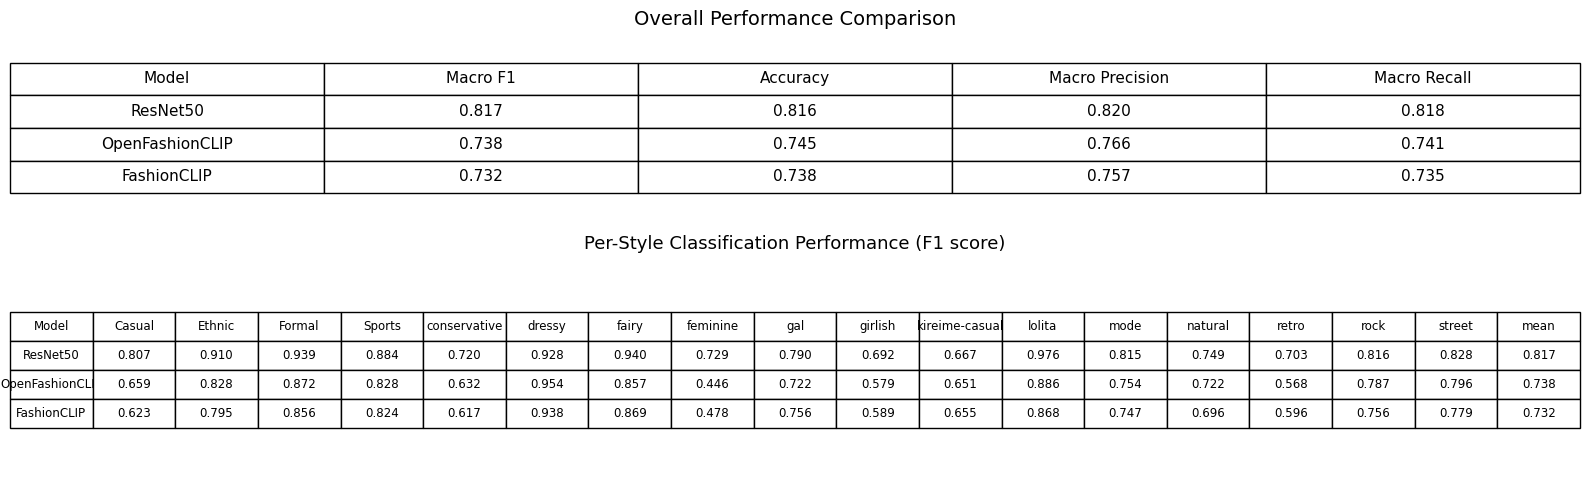

Saved: baseline_result\style_3\figures\baseline_comparison_table.png

Baseline | Split: style_4
Train shape: (11784, 2)
Val shape  : (2525, 2)
Test shape : (2526, 2)

Train distribution:
style
street            791
gal               752
mode              737
conservative      732
girlish           729
natural           706
retro             705
Sports            700
Casual            700
Formal            700
Ethnic            700
kireime-casual    692
lolita            684
rock              682
dressy            620
fairy             615
feminine          539
Name: count, dtype: int64

Number of classes: 17
Labels: ['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']

Style label to index mapping:
  Casual -> 0
  Ethnic -> 1
  Formal -> 2
  Sports -> 3
  conservative -> 4
  dressy -> 5
  fairy -> 6
  feminine -> 7
  gal -> 8
  girlish -> 9
  kireime-casual -> 

Training:   0%|          | 0/369 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train loss         : 1.1804
Val loss           : 0.6903
Val accuracy       : 0.7683
Val macro precision: 0.7828
Val macro recall   : 0.7708
Val macro F1       : 0.7657
Best checkpoint updated.

===== ResNet50 | Epoch 2/10 =====


Training:   0%|          | 0/369 [00:00<?, ?it/s]

...

Saved inference results: baseline_result\style_4\predictions\ResNet50_test_predictions.csv


Inference [OpenFashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_4\predictions\OpenFashionCLIP_test_predictions.csv


Inference [FashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_4\predictions\FashionCLIP_test_predictions.csv

===== Evaluation [ResNet50] =====
Accuracy       : 0.8112
Macro Precision: 0.8164
Macro Recall   : 0.8137
Macro F1       : 0.8132
Saved per-style metrics: baseline_result\style_4\metrics\ResNet50_per_style_metrics.csv

===== Evaluation [OpenFashionCLIP] =====
Accuracy       : 0.7320
Macro Precision: 0.7606
Macro Recall   : 0.7288
Macro F1       : 0.7260
Saved per-style metrics: baseline_result\style_4\metrics\OpenFashionCLIP_per_style_metrics.csv

===== Evaluation [FashionCLIP] =====
Accuracy       : 0.7328
Macro Precision: 0.7616
Macro Recall   : 0.7290
Macro F1       : 0.7267
Saved per-style metrics: baseline_result\style_4\metrics\FashionCLIP_per_style_metrics.csv
Saved: baseline_result\style_4\metrics\overall_performance_comparison.csv
             Model  Macro F1  Accuracy  Macro Precision  Macro Recall
0         ResNet50  0.813157  0.811164         0.816405      0.813727
1  OpenFashionC

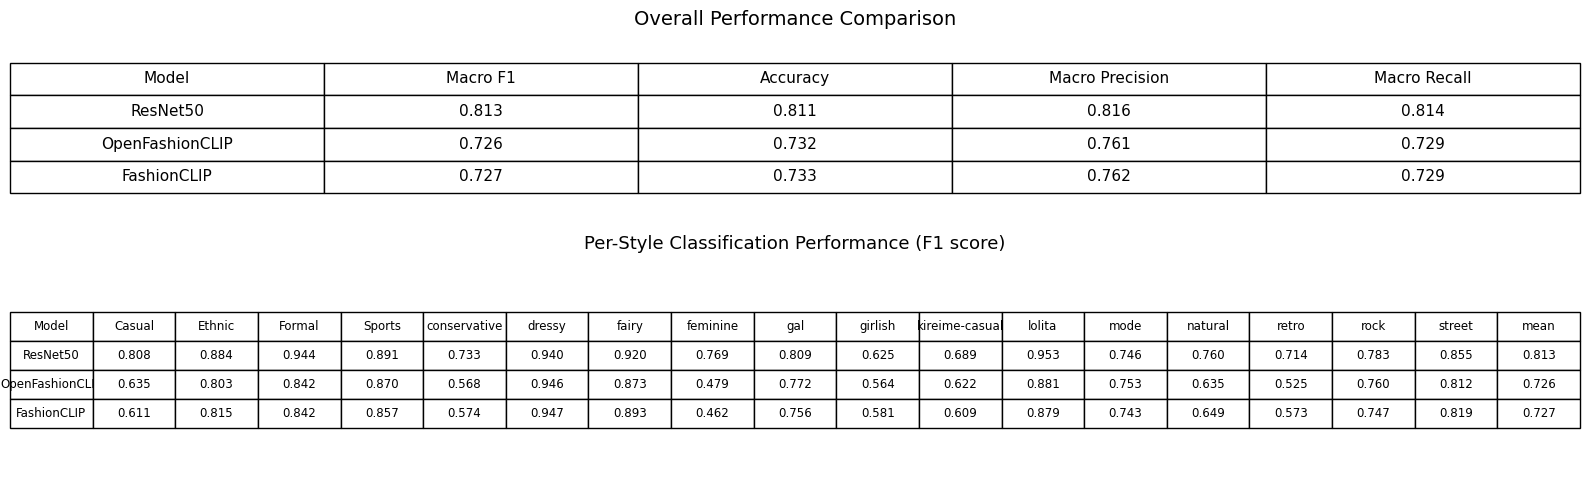

Saved: baseline_result\style_4\figures\baseline_comparison_table.png

Baseline | Split: style_5
Train shape: (11784, 2)
Val shape  : (2525, 2)
Test shape : (2526, 2)

Train distribution:
style
street            791
gal               752
mode              737
conservative      732
girlish           729
natural           706
retro             705
Ethnic            700
Sports            700
Casual            700
Formal            700
kireime-casual    692
lolita            684
rock              682
dressy            620
fairy             615
feminine          539
Name: count, dtype: int64

Number of classes: 17
Labels: ['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']

Style label to index mapping:
  Casual -> 0
  Ethnic -> 1
  Formal -> 2
  Sports -> 3
  conservative -> 4
  dressy -> 5
  fairy -> 6
  feminine -> 7
  gal -> 8
  girlish -> 9
  kireime-casual -> 

Training:   0%|          | 0/369 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train loss         : 1.1609
Val loss           : 0.7088
Val accuracy       : 0.7556
Val macro precision: 0.7773
Val macro recall   : 0.7572
Val macro F1       : 0.7549
Best checkpoint updated.

===== ResNet50 | Epoch 2/10 =====


Training:   0%|          | 0/369 [00:00<?, ?it/s]

...

Saved inference results: baseline_result\style_5\predictions\ResNet50_test_predictions.csv


Inference [OpenFashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_5\predictions\OpenFashionCLIP_test_predictions.csv


Inference [FashionCLIP | test]:   0%|          | 0/79 [00:00<?, ?it/s]

Saved inference results: baseline_result\style_5\predictions\FashionCLIP_test_predictions.csv

===== Evaluation [ResNet50] =====
Accuracy       : 0.7937
Macro Precision: 0.7944
Macro Recall   : 0.7958
Macro F1       : 0.7937
Saved per-style metrics: baseline_result\style_5\metrics\ResNet50_per_style_metrics.csv

===== Evaluation [OpenFashionCLIP] =====
Accuracy       : 0.7403
Macro Precision: 0.7650
Macro Recall   : 0.7362
Macro F1       : 0.7353
Saved per-style metrics: baseline_result\style_5\metrics\OpenFashionCLIP_per_style_metrics.csv

===== Evaluation [FashionCLIP] =====
Accuracy       : 0.7371
Macro Precision: 0.7580
Macro Recall   : 0.7336
Macro F1       : 0.7317
Saved per-style metrics: baseline_result\style_5\metrics\FashionCLIP_per_style_metrics.csv
Saved: baseline_result\style_5\metrics\overall_performance_comparison.csv
             Model  Macro F1  Accuracy  Macro Precision  Macro Recall
0         ResNet50  0.793732  0.793745         0.794440      0.795763
1  OpenFashionC

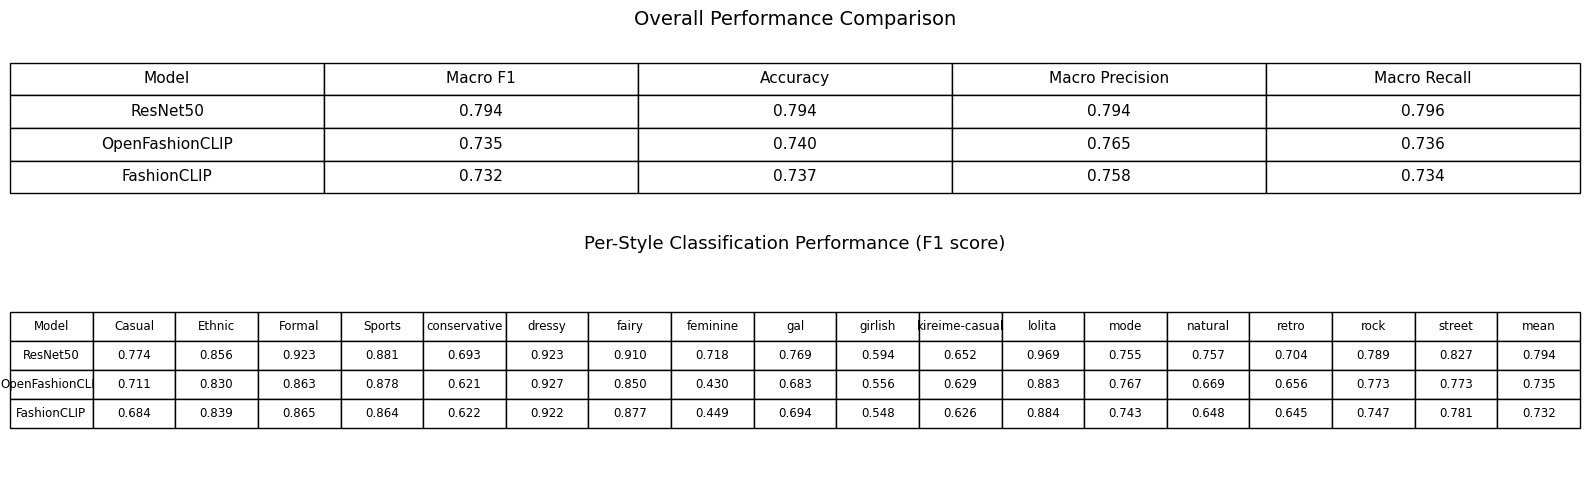

Saved: baseline_result\style_5\figures\baseline_comparison_table.png


In [5]:
VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

def build_image_lookup(image_dir):
    """Build a dictionary: image_id -> full_path."""
    lookup = {}
    for fname in os.listdir(image_dir):
        fpath = os.path.join(image_dir, fname)
        if not os.path.isfile(fpath):
            continue
        stem, ext = os.path.splitext(fname)
        if ext.lower() in VALID_EXTS:
            lookup[stem] = fpath
    return lookup


# Collect all results across splits for final summary
baseline_all_results = {}  # split_name -> {model_name -> {overall, per_style}}

for split_name in SPLIT_FOLDERS:
    print(f"\n{'='*60}")
    print(f"Baseline | Split: {split_name}")
    print(f"{'='*60}")

    # Set output directories for this split (used by train_model, run_inference, evaluate_predictions)
    BASELINE_DIR = Path(f"baseline_result/{split_name}")
    CKPT_DIR     = BASELINE_DIR / "checkpoints"
    PRED_DIR     = BASELINE_DIR / "predictions"
    METRIC_DIR   = BASELINE_DIR / "metrics"
    FIG_DIR      = BASELINE_DIR / "figures"

    for p in [BASELINE_DIR, CKPT_DIR, PRED_DIR, METRIC_DIR, FIG_DIR]:
        os.makedirs(p, exist_ok=True)

    # Load CSVs
    paths = get_split_paths(split_name)
    train_df = pd.read_csv(paths["train_csv"])
    val_df   = pd.read_csv(paths["val_csv"])
    test_df  = pd.read_csv(paths["test_csv"])

    train_df["id"] = train_df["id"].astype(str)
    val_df["id"]   = val_df["id"].astype(str)
    test_df["id"]  = test_df["id"].astype(str)

    print("Train shape:", train_df.shape)
    print("Val shape  :", val_df.shape)
    print("Test shape :", test_df.shape)

    print("\nTrain distribution:")
    print(train_df["style"].value_counts())

    style_names = sorted(train_df["style"].unique())
    label2idx = {label: idx for idx, label in enumerate(style_names)}
    idx2label = {idx: label for label, idx in label2idx.items()}
    num_classes = len(style_names)

    print("\nNumber of classes:", num_classes)
    print("Labels:", style_names)

    with open(os.path.join(METRIC_DIR, "label_mapping.json"), "w") as f:
        json.dump(
            {"label2idx": label2idx, "idx2label": {str(k): v for k, v in idx2label.items()}},
            f, indent=2
        )

    print("\nStyle label to index mapping:")
    for style, idx in label2idx.items():
        print(f"  {style} -> {idx}")

    # Build image lookups
    train_lookup = build_image_lookup(paths["train_img_dir"])
    val_lookup   = build_image_lookup(paths["val_img_dir"])
    test_lookup  = build_image_lookup(paths["test_img_dir"])

    print("\nTrain images:", len(train_lookup))
    print("Val images  :", len(val_lookup))
    print("Test images :", len(test_lookup))

    # Build datasets
    resnet_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, transform=resnet_train_tf)
    resnet_val_ds   = StyleImageDataset(val_df,   val_lookup,   label2idx, transform=resnet_eval_tf)
    resnet_test_ds  = StyleImageDataset(test_df,  test_lookup,  label2idx, transform=resnet_eval_tf)

    ofc_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, transform=openclip_preprocess)
    ofc_val_ds   = StyleImageDataset(val_df,   val_lookup,   label2idx, transform=openclip_preprocess)
    ofc_test_ds  = StyleImageDataset(test_df,  test_lookup,  label2idx, transform=openclip_preprocess)

    fclip_train_ds = StyleImageRawDataset(train_df, train_lookup, label2idx)
    fclip_val_ds   = StyleImageRawDataset(val_df,   val_lookup,   label2idx)
    fclip_test_ds  = StyleImageRawDataset(test_df,  test_lookup,  label2idx)

    # Build dataloaders
    resnet_train_loader = DataLoader(resnet_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    resnet_val_loader   = DataLoader(resnet_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    resnet_test_loader  = DataLoader(resnet_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    ofc_train_loader = DataLoader(ofc_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    ofc_val_loader   = DataLoader(ofc_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    ofc_test_loader  = DataLoader(ofc_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    fclip_train_loader = DataLoader(fclip_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, collate_fn=fashionclip_collate_fn)
    fclip_val_loader   = DataLoader(fclip_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=fashionclip_collate_fn)
    fclip_test_loader  = DataLoader(fclip_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=fashionclip_collate_fn)

    # ---- ResNet50 ----
    resnet_model = ResNet50Classifier(num_classes=num_classes)
    resnet_train_result = train_model(
        model_name="ResNet50", model=resnet_model,
        train_loader=resnet_train_loader, val_loader=resnet_val_loader,
        device=DEVICE, num_epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
    )

    # ---- OpenFashionCLIP ----
    ofc_model = OpenFashionCLIPClassifier(
        num_classes=num_classes,
        model_name=OPENFASHIONCLIP_MODEL_NAME,
        pretrained=OPENFASHIONCLIP_PRETRAINED
    )
    ofc_train_result = train_model(
        model_name="OpenFashionCLIP", model=ofc_model,
        train_loader=ofc_train_loader, val_loader=ofc_val_loader,
        device=DEVICE, num_epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
    )

    # ---- FashionCLIP ----
    fclip_model = FashionCLIPClassifier(num_classes=num_classes, model_id=FASHIONCLIP_MODEL_ID)
    fclip_train_result = train_model(
        model_name="FashionCLIP", model=fclip_model,
        train_loader=fclip_train_loader, val_loader=fclip_val_loader,
        device=DEVICE, num_epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
    )

    # Load best checkpoints for inference
    resnet_model = ResNet50Classifier(num_classes=num_classes)
    resnet_model.load_state_dict(torch.load(resnet_train_result["best_ckpt_path"], map_location=DEVICE))
    resnet_model = resnet_model.to(DEVICE)

    ofc_model = OpenFashionCLIPClassifier(
        num_classes=num_classes,
        model_name=OPENFASHIONCLIP_MODEL_NAME,
        pretrained=OPENFASHIONCLIP_PRETRAINED
    )
    ofc_model.load_state_dict(torch.load(ofc_train_result["best_ckpt_path"], map_location=DEVICE))
    ofc_model = ofc_model.to(DEVICE)

    fclip_model = FashionCLIPClassifier(num_classes=num_classes, model_id=FASHIONCLIP_MODEL_ID)
    fclip_model.load_state_dict(torch.load(fclip_train_result["best_ckpt_path"], map_location=DEVICE))
    fclip_model = fclip_model.to(DEVICE)

    # Inference
    resnet_test_pred = run_inference(
        model_name="ResNet50", model=resnet_model,
        loader=resnet_test_loader, device=DEVICE, idx2label=idx2label, split_name="test"
    )
    ofc_test_pred = run_inference(
        model_name="OpenFashionCLIP", model=ofc_model,
        loader=ofc_test_loader, device=DEVICE, idx2label=idx2label, split_name="test"
    )
    fclip_test_pred = run_inference(
        model_name="FashionCLIP", model=fclip_model,
        loader=fclip_test_loader, device=DEVICE, idx2label=idx2label, split_name="test"
    )

    # Evaluation
    resnet_overall, resnet_per_style = evaluate_predictions(resnet_test_pred, "ResNet50")
    ofc_overall, ofc_per_style       = evaluate_predictions(ofc_test_pred, "OpenFashionCLIP")
    fclip_overall, fclip_per_style   = evaluate_predictions(fclip_test_pred, "FashionCLIP")

    # Save overall comparison for this split
    overall_df = pd.DataFrame([resnet_overall, ofc_overall, fclip_overall])
    overall_df = overall_df.rename(columns={
        "model": "Model", "macro_f1": "Macro F1", "accuracy": "Accuracy",
        "macro_precision": "Macro Precision", "macro_recall": "Macro Recall"
    })

    overall_csv_path = os.path.join(METRIC_DIR, "overall_performance_comparison.csv")
    overall_df.to_csv(overall_csv_path, index=False)
    print("Saved:", overall_csv_path)
    print(overall_df)

    # Save per-style F1 comparison for this split
    per_style_compare = pd.DataFrame({"style": style_names})
    per_style_compare = per_style_compare.merge(
        resnet_per_style[["style", "f1"]].rename(columns={"f1": "ResNet50"}), on="style", how="left"
    )
    per_style_compare = per_style_compare.merge(
        ofc_per_style[["style", "f1"]].rename(columns={"f1": "OpenFashionCLIP"}), on="style", how="left"
    )
    per_style_compare = per_style_compare.merge(
        fclip_per_style[["style", "f1"]].rename(columns={"f1": "FashionCLIP"}), on="style", how="left"
    )

    per_style_csv_path = os.path.join(METRIC_DIR, "per_style_f1_comparison.csv")
    per_style_compare.to_csv(per_style_csv_path, index=False)
    print("Saved:", per_style_csv_path)
    print(per_style_compare)

    # Draw comparison figure for this split
    figure_path = os.path.join(FIG_DIR, "baseline_comparison_table.png")
    draw_comparison_figure(overall_df, per_style_compare, figure_path)
    print("Saved:", figure_path)

    # Store results for cross-split summary
    baseline_all_results[split_name] = {
        "ResNet50":        {"overall": resnet_overall,    "per_style": resnet_per_style},
        "OpenFashionCLIP": {"overall": ofc_overall,       "per_style": ofc_per_style},
        "FashionCLIP":     {"overall": fclip_overall,     "per_style": fclip_per_style},
    }

## Baseline Summary: Mean and Std Across Splits

Baseline Summary (mean +/- std across 5 splits):
                          Macro F1           Accuracy    Macro Precision       Macro Recall
Model                                                                                      
ResNet50         0.8053 +/- 0.0106  0.8039 +/- 0.0107  0.8084 +/- 0.0103  0.8059 +/- 0.0111
OpenFashionCLIP  0.7327 +/- 0.0065  0.7386 +/- 0.0066  0.7633 +/- 0.0037  0.7351 +/- 0.0064
FashionCLIP      0.7321 +/- 0.0041  0.7382 +/- 0.0041  0.7615 +/- 0.0041  0.7346 +/- 0.0041

Saved: baseline_result/summary/baseline_summary.csv


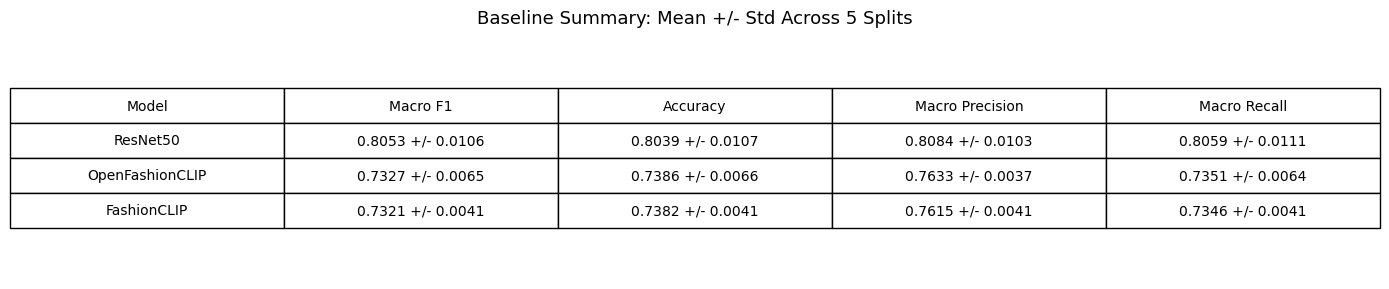

In [6]:
# Aggregate overall metrics across splits for each model
baseline_models = ["ResNet50", "OpenFashionCLIP", "FashionCLIP"]
metric_keys = ["macro_f1", "accuracy", "macro_precision", "macro_recall"]

summary_rows = []

for model_name in baseline_models:
    model_metrics = {k: [] for k in metric_keys}

    for split_name in SPLIT_FOLDERS:
        if split_name not in baseline_all_results:
            continue
        result = baseline_all_results[split_name][model_name]["overall"]
        for k in metric_keys:
            model_metrics[k].append(result[k])

    row = {"Model": model_name}
    for k in metric_keys:
        values = model_metrics[k]
        mean_val = np.mean(values)
        std_val  = np.std(values)
        col_name = k.replace("_", " ").title()
        row[col_name] = f"{mean_val:.4f} +/- {std_val:.4f}"
    summary_rows.append(row)

baseline_summary_df = pd.DataFrame(summary_rows)
baseline_summary_df = baseline_summary_df.set_index("Model")

print("Baseline Summary (mean +/- std across 5 splits):")
print(baseline_summary_df.to_string())

# Save summary
os.makedirs("baseline_result/summary", exist_ok=True)
baseline_summary_df.to_csv("baseline_result/summary/baseline_summary.csv")
print("\nSaved: baseline_result/summary/baseline_summary.csv")

# Display as figure
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")
ax.set_title("Baseline Summary: Mean +/- Std Across 5 Splits", fontsize=13, pad=10)

display_df = baseline_summary_df.reset_index()
table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
plt.tight_layout()
plt.savefig("baseline_result/summary/baseline_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

## Mean and std for all the metrics

In [47]:
import os
import pandas as pd
from tabulate import tabulate

root_dir = "baseline_result"
style_folders = [f"style_{i}" for i in range(1, 6)]


def format_mean_std(mean_val, std_val):
    return f"{mean_val:.2f} ± {std_val:.2f}"


def clean_dataframe(df):
    # Strip whitespace from column names
    df.columns = [str(col).strip() for col in df.columns]
    return df


def detect_key_column(df):
    # Clean column names first
    cols = [str(col).strip() for col in df.columns]

    # Priority 1: standard column names
    if "Model" in cols:
        return "Model"
    if "Experiment" in cols:
        return "Experiment"

    # Priority 2: unnamed index column
    unnamed_cols = [col for col in cols if col.startswith("Unnamed:")]
    if unnamed_cols:
        return unnamed_cols[0]

    # Priority 3: use the first column as fallback
    return cols[0]


def aggregate_overall_performance():
    dfs = []

    for folder in style_folders:
        file_path = os.path.join(
            root_dir, folder, "metrics", "overall_performance_comparison.csv"
        )
        df = pd.read_csv(file_path)
        df = clean_dataframe(df)
        dfs.append(df)

    combined_df = pd.concat(dfs, ignore_index=True)
    key_col = detect_key_column(combined_df)

    numeric_cols = ["Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]

    mean_df = combined_df.groupby(key_col)[numeric_cols].mean()
    std_df = combined_df.groupby(key_col)[numeric_cols].std()

    result_df = mean_df.copy()

    for col in numeric_cols:
        result_df[col] = [
            format_mean_std(m, s)
            for m, s in zip(mean_df[col], std_df[col])
        ]

    result_df = result_df.reset_index()
    result_df = result_df.rename(columns={key_col: "Model"})

    return result_df


def aggregate_per_style_f1():
    dfs = []

    for folder in style_folders:
        file_path = os.path.join(
            root_dir, folder, "metrics", "per_style_f1_comparison.csv"
        )
        df = pd.read_csv(file_path)
        df = clean_dataframe(df)
        dfs.append(df)

    combined_df = pd.concat(dfs, ignore_index=True)
    key_col = detect_key_column(combined_df)

    # Convert non-key columns to numeric when possible
    for col in combined_df.columns:
        if col != key_col:
            combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

    numeric_cols = [col for col in combined_df.columns if col != key_col]

    long_df = combined_df.melt(
        id_vars=key_col,
        value_vars=numeric_cols,
        var_name="Style",
        value_name="F1"
    )

    # Remove rows with NaN values
    long_df = long_df.dropna(subset=["F1"])

    stats_df = (
        long_df.groupby([key_col, "Style"])["F1"]
        .agg(["mean", "std"])
        .reset_index()
    )

    stats_df["F1_str"] = [
        format_mean_std(m, s)
        for m, s in zip(stats_df["mean"], stats_df["std"])
    ]

    wide_df = stats_df.pivot(
        index=key_col,
        columns="Style",
        values="F1_str"
    ).reset_index()

    wide_df = wide_df.rename(columns={key_col: "Model"})

    return wide_df


def print_table(title, df):
    print(f"\n{title}\n")
    print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))


overall_result = aggregate_overall_performance()
per_style_result = aggregate_per_style_f1()

print_table("Overall Performance (Mean ± Std)", overall_result)
print_table("Per-Style F1 (Mean ± Std)", per_style_result)


Overall Performance (Mean ± Std)

+-----------------+-------------+-------------+-------------------+----------------+
| Model           | Macro F1    | Accuracy    | Macro Precision   | Macro Recall   |
+=================+=============+=============+===================+================+
| FashionCLIP     | 0.73 ± 0.00 | 0.74 ± 0.00 | 0.76 ± 0.00       | 0.73 ± 0.00    |
+-----------------+-------------+-------------+-------------------+----------------+
| OpenFashionCLIP | 0.73 ± 0.01 | 0.74 ± 0.01 | 0.76 ± 0.00       | 0.74 ± 0.01    |
+-----------------+-------------+-------------+-------------------+----------------+
| ResNet50        | 0.81 ± 0.01 | 0.80 ± 0.01 | 0.81 ± 0.01       | 0.81 ± 0.01    |
+-----------------+-------------+-------------+-------------------+----------------+

Per-Style F1 (Mean ± Std)

+----------------+---------------+-------------------+-------------+
| Model          | FashionCLIP   | OpenFashionCLIP   | ResNet50    |
+================+===============+

# Part 2: Fine-Tuning Experiments

In [17]:
import os
import json
import copy
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import open_clip
from transformers import AutoProcessor, AutoTokenizer, CLIPModel

warnings.filterwarnings("ignore")

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
HEAD_LR = 1e-4
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OPENFASHIONCLIP_MODEL_NAME = "ViT-B-32"
OPENFASHIONCLIP_PRETRAINED = "laion2b_s34b_b79k"
FASHIONCLIP_MODEL_ID = "patrickjohncyh/fashion-clip"

DATA_ROOT = Path(os.path.join("..", "..", "1_data", "Style_dataset"))
SPLIT_FOLDERS = [f"style_{i}" for i in range(1, 6)]

def get_split_paths(split_name):
    """Return data paths for a given split folder."""
    split_root = DATA_ROOT / split_name
    return {
        "split_root":    split_root,
        "train_csv":     split_root / "train.csv",
        "val_csv":       split_root / "val.csv",
        "test_csv":      split_root / "test.csv",
        "train_img_dir": split_root / "images" / "train",
        "val_img_dir":   split_root / "images" / "val",
        "test_img_dir":  split_root / "images" / "test",
    }

print("Device:", DEVICE)

Device: cuda


## Class and Function Definitions

In [18]:
class StyleImageDataset(Dataset):
    def __init__(self, df, image_lookup, label2idx, image_transform=None):
        self.image_lookup = image_lookup
        self.label2idx = label2idx
        self.image_transform = image_transform

        rows = []
        missing = 0
        for _, row in df.iterrows():
            image_id = str(row["id"])
            if image_id in self.image_lookup:
                rows.append(row)
            else:
                missing += 1

        self.df = pd.DataFrame(rows).reset_index(drop=True)
        print(f"Dataset initialized with {len(self.df)} rows, missing images skipped: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["id"])
        label_name = row["style"]
        label = self.label2idx[label_name]
        image = Image.open(self.image_lookup[image_id]).convert("RGB")
        if self.image_transform is not None:
            image = self.image_transform(image)
        return {"id": image_id, "image": image, "label": label, "label_name": label_name}

In [19]:
VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

def build_image_lookup(image_dir):
    """Build a dictionary: image_id -> full_path."""
    lookup = {}
    for fname in os.listdir(image_dir):
        fpath = os.path.join(image_dir, fname)
        if not os.path.isfile(fpath):
            continue
        stem, ext = os.path.splitext(fname)
        if ext.lower() in VALID_EXTS:
            lookup[stem] = fpath
    return lookup


def create_exp_dirs(exp_name):
    exp_dir    = os.path.join(EXP_ROOT, exp_name)
    ckpt_dir   = os.path.join(exp_dir, "checkpoints")
    pred_dir   = os.path.join(exp_dir, "predictions")
    metric_dir = os.path.join(exp_dir, "metrics")
    fig_dir    = os.path.join(exp_dir, "figures")
    log_dir    = os.path.join(exp_dir, "logs")
    for p in [exp_dir, ckpt_dir, pred_dir, metric_dir, fig_dir, log_dir]:
        os.makedirs(p, exist_ok=True)
    return {"exp_dir": exp_dir, "ckpt_dir": ckpt_dir, "pred_dir": pred_dir,
            "metric_dir": metric_dir, "fig_dir": fig_dir, "log_dir": log_dir}


def compute_metrics(y_true, y_pred, idx2label):
    acc = accuracy_score(y_true, y_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    label_ids = list(range(len(idx2label)))
    per_precision, per_recall, per_f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=label_ids, average=None, zero_division=0
    )
    per_style_df = pd.DataFrame({
        "style":     [idx2label[i] for i in label_ids],
        "precision": per_precision,
        "recall":    per_recall,
        "f1":        per_f1,
        "support":   support
    })
    overall = {
        "Macro F1": macro_f1, "Accuracy": acc,
        "Macro Precision": macro_precision, "Macro Recall": macro_recall
    }
    return overall, per_style_df


def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

def unfreeze_last_openclip_blocks(model, n_last_blocks=2):
    freeze_all(model)
    for p in model.classifier.parameters():
        p.requires_grad = True
    if hasattr(model.backbone.visual, "transformer") and hasattr(model.backbone.visual.transformer, "resblocks"):
        blocks = model.backbone.visual.transformer.resblocks
        for block in list(blocks)[-n_last_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

def unfreeze_last_fashionclip_blocks(model, n_last_blocks=2):
    freeze_all(model)
    for p in model.classifier.parameters():
        p.requires_grad = True
    if hasattr(model.backbone.vision_model.encoder, "layers"):
        blocks = model.backbone.vision_model.encoder.layers
        for block in list(blocks)[-n_last_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

def build_optimizer(model, head_lr=1e-4, backbone_lr=1e-5, weight_decay=1e-4):
    head_params     = []
    backbone_params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if "classifier" in name or "adapter" in name or "logit_scale" in name:
            head_params.append(p)
        else:
            backbone_params.append(p)
    param_groups = []
    if head_params:
        param_groups.append({"params": head_params,     "lr": head_lr})
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": backbone_lr})
    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)

In [20]:
class OpenFashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_name, pretrained):
        super().__init__()
        self.backbone = open_clip.create_model(model_name, pretrained=pretrained)
        if hasattr(self.backbone.visual, "output_dim"):
            feat_dim = self.backbone.visual.output_dim
        else:
            raise ValueError("Could not determine OpenFashionCLIP visual output dimension.")
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        image_features = self.backbone.encode_image(pixel_values)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits


class FashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_id):
        super().__init__()
        self.backbone = CLIPModel.from_pretrained(model_id)
        feat_dim = self.backbone.config.projection_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_output  = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits


class OpenFashionCLIPPromptClassifier(nn.Module):
    def __init__(self, style_names, model_name, pretrained, prompt_template="a photo of a {} fashion outfit"):
        super().__init__()
        self.backbone  = open_clip.create_model(model_name, pretrained=pretrained)
        self.tokenizer = open_clip.get_tokenizer(model_name)
        prompts    = [prompt_template.format(style) for style in style_names]
        tokenized  = self.tokenizer(prompts)
        with torch.no_grad():
            text_features = self.backbone.encode_text(tokenized)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        self.register_buffer("text_features", text_features)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))
        feat_dim = text_features.shape[1]
        self.adapter = nn.Linear(feat_dim, feat_dim)
        nn.init.eye_(self.adapter.weight)
        nn.init.zeros_(self.adapter.bias)

    def forward(self, pixel_values):
        image_features = self.backbone.encode_image(pixel_values)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        image_features = self.adapter(image_features)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.logit_scale.exp() * image_features @ self.text_features.T
        return logits


class FashionCLIPPromptClassifier(nn.Module):
    def __init__(self, style_names, model_id, prompt_template="a photo of a {} fashion outfit"):
        super().__init__()
        self.backbone  = CLIPModel.from_pretrained(model_id)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        prompts     = [prompt_template.format(style) for style in style_names]
        text_inputs = self.tokenizer(prompts, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            text_outputs  = self.backbone.text_model(
                input_ids=text_inputs["input_ids"],
                attention_mask=text_inputs["attention_mask"]
            )
            pooled_text   = text_outputs.pooler_output
            text_features = self.backbone.text_projection(pooled_text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        self.register_buffer("text_features", text_features)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))
        feat_dim = text_features.shape[1]
        self.adapter = nn.Linear(feat_dim, feat_dim)
        nn.init.eye_(self.adapter.weight)
        nn.init.zeros_(self.adapter.bias)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_image   = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_image)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        image_features = self.adapter(image_features)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.logit_scale.exp() * image_features @ self.text_features.T
        return logits


try:
    from peft import LoraConfig, get_peft_model
    PEFT_AVAILABLE = True
except Exception:
    PEFT_AVAILABLE = False

print("PEFT available:", PEFT_AVAILABLE)


class FashionCLIPLoRAClassifier(nn.Module):
    def __init__(self, num_classes, model_id):
        super().__init__()
        base_model = CLIPModel.from_pretrained(model_id)
        if not PEFT_AVAILABLE:
            raise ImportError("peft is not installed. Please install peft before running LoRA experiments.")
        lora_config = LoraConfig(
            r=8, lora_alpha=16,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
            lora_dropout=0.1, bias="none"
        )
        self.backbone  = get_peft_model(base_model, lora_config)
        feat_dim       = self.backbone.config.projection_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_output  = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits

PEFT available: True


In [21]:
def train_model(exp_name, model, train_loader, val_loader, num_epochs,
                idx2label, save_dirs, head_lr=1e-4, backbone_lr=1e-5, weight_decay=1e-4):
    model = model.to(DEVICE)
    optimizer = build_optimizer(model, head_lr=head_lr, backbone_lr=backbone_lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    best_state  = None
    best_val_f1 = -1
    history     = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for batch in tqdm(train_loader, desc=f"{exp_name} Train Epoch {epoch}", leave=False):
            images = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * labels.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        all_true, all_pred = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"{exp_name} Val Epoch {epoch}", leave=False):
                images = batch["image"].to(DEVICE)
                labels = batch["label"].to(DEVICE)
                logits = model(images)
                loss   = criterion(logits, labels)
                preds  = torch.argmax(logits, dim=1)
                val_loss_sum += loss.item() * labels.size(0)
                all_true.extend(labels.cpu().numpy().tolist())
                all_pred.extend(preds.cpu().numpy().tolist())

        val_loss    = val_loss_sum / len(val_loader.dataset)
        val_overall, _ = compute_metrics(all_true, all_pred, idx2label)

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "val_macro_f1": val_overall["Macro F1"], "val_accuracy": val_overall["Accuracy"]
        })

        print(f"\n===== {exp_name} | Epoch {epoch}/{num_epochs} =====")
        print(f"Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}")
        print(f"Val Accuracy: {val_overall['Accuracy']:.4f}  |  Val Macro F1: {val_overall['Macro F1']:.4f}")

        if val_overall["Macro F1"] > best_val_f1:
            best_val_f1 = val_overall["Macro F1"]
            best_state  = copy.deepcopy(model.state_dict())
            print("Best checkpoint updated.")

    history_df   = pd.DataFrame(history)
    history_path = os.path.join(save_dirs["log_dir"], "training_history.csv")
    history_df.to_csv(history_path, index=False)

    ckpt_path = os.path.join(save_dirs["ckpt_dir"], "best.pt")
    torch.save(best_state, ckpt_path)

    print(f"\nSaved history   : {history_path}")
    print(f"Saved checkpoint: {ckpt_path}")

    return {"best_ckpt_path": ckpt_path, "history_df": history_df, "best_val_f1": best_val_f1}


@torch.no_grad()
def run_inference(model, loader, save_path):
    model.eval()
    all_ids, all_true, all_pred = [], [], []

    for batch in tqdm(loader, desc="Inference", leave=False):
        images = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        logits = model(images)
        preds  = torch.argmax(logits, dim=1)
        all_ids.extend(batch["id"])
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    pred_df = pd.DataFrame({
        "id":         all_ids,
        "true_idx":   all_true,
        "pred_idx":   all_pred,
        "true_label": [idx2label[x] for x in all_true],
        "pred_label": [idx2label[x] for x in all_pred]
    })
    pred_df["correct"] = (pred_df["true_idx"] == pred_df["pred_idx"]).astype(int)
    pred_df.to_csv(save_path, index=False)
    print(f"Saved predictions: {save_path}")
    return pred_df


def evaluate_predictions(pred_df, metric_dir):
    y_true = pred_df["true_idx"].tolist()
    y_pred = pred_df["pred_idx"].tolist()
    overall, per_style_df = compute_metrics(y_true, y_pred, idx2label)
    pd.DataFrame([overall]).to_csv(os.path.join(metric_dir, "overall_metrics.csv"), index=False)
    per_style_df.to_csv(os.path.join(metric_dir, "per_style_metrics.csv"), index=False)
    return pd.DataFrame([overall]), per_style_df

In [22]:
set_seed(SEED)

# OpenCLIP preprocess (initialized once)
openclip_model_tmp, _, openclip_preprocess = open_clip.create_model_and_transforms(
    OPENFASHIONCLIP_MODEL_NAME, pretrained=OPENFASHIONCLIP_PRETRAINED
)
del openclip_model_tmp

# FashionCLIP processor (initialized once)
fashionclip_processor = AutoProcessor.from_pretrained(FASHIONCLIP_MODEL_ID)

def fashionclip_collate_fn(batch):
    images      = [x["image"] for x in batch]
    labels      = torch.tensor([x["label"] for x in batch], dtype=torch.long)
    ids         = [x["id"] for x in batch]
    label_names = [x["label_name"] for x in batch]
    pixel_values = fashionclip_processor(images=images, return_tensors="pt")["pixel_values"]
    return {"id": ids, "image": pixel_values, "label": labels, "label_name": label_names}

print("Preprocessors initialized.")

Preprocessors initialized.


In [23]:
def build_experiment(exp_name, num_classes, style_names):
    """Build model and return (model, train_loader, val_loader, test_loader)."""
    if exp_name == "openfashionclip_partial_ft":
        model = OpenFashionCLIPClassifier(num_classes, OPENFASHIONCLIP_MODEL_NAME, OPENFASHIONCLIP_PRETRAINED)
        unfreeze_last_openclip_blocks(model, n_last_blocks=2)
        return model, open_train_loader, open_val_loader, open_test_loader

    if exp_name == "openfashionclip_full_ft":
        model = OpenFashionCLIPClassifier(num_classes, OPENFASHIONCLIP_MODEL_NAME, OPENFASHIONCLIP_PRETRAINED)
        unfreeze_all(model)
        return model, open_train_loader, open_val_loader, open_test_loader

    if exp_name == "openfashionclip_prompt":
        model = OpenFashionCLIPPromptClassifier(style_names, OPENFASHIONCLIP_MODEL_NAME, OPENFASHIONCLIP_PRETRAINED)
        freeze_all(model.backbone)
        for p in model.adapter.parameters():
            p.requires_grad = True
        model.logit_scale.requires_grad = True
        return model, open_train_loader, open_val_loader, open_test_loader

    if exp_name == "fashionclip_partial_ft":
        model = FashionCLIPClassifier(num_classes, FASHIONCLIP_MODEL_ID)
        unfreeze_last_fashionclip_blocks(model, n_last_blocks=2)
        return model, fclip_train_loader, fclip_val_loader, fclip_test_loader

    if exp_name == "fashionclip_full_ft":
        model = FashionCLIPClassifier(num_classes, FASHIONCLIP_MODEL_ID)
        unfreeze_all(model)
        return model, fclip_train_loader, fclip_val_loader, fclip_test_loader

    if exp_name == "fashionclip_prompt":
        model = FashionCLIPPromptClassifier(style_names, FASHIONCLIP_MODEL_ID)
        freeze_all(model.backbone)
        for p in model.adapter.parameters():
            p.requires_grad = True
        model.logit_scale.requires_grad = True
        return model, fclip_train_loader, fclip_val_loader, fclip_test_loader

    if exp_name == "fashionclip_lora":
        model = FashionCLIPLoRAClassifier(num_classes, FASHIONCLIP_MODEL_ID)
        for p in model.classifier.parameters():
            p.requires_grad = True
        return model, fclip_train_loader, fclip_val_loader, fclip_test_loader

    raise ValueError(f"Unknown experiment name: {exp_name}")


def rebuild_model_for_inference(exp_name, ckpt_path, num_classes, style_names):
    model, _, _, test_loader = build_experiment(exp_name, num_classes, style_names)
    state_dict = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model = model.to(DEVICE)
    return model, test_loader


def run_single_experiment(exp_name, num_classes, style_names):
    print(f"\n===== Running {exp_name} =====")
    save_dirs = create_exp_dirs(exp_name)
    model, train_loader, val_loader, test_loader = build_experiment(exp_name, num_classes, style_names)

    train_result = train_model(
        exp_name=exp_name, model=model,
        train_loader=train_loader, val_loader=val_loader,
        num_epochs=NUM_EPOCHS, idx2label=idx2label, save_dirs=save_dirs,
        head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, weight_decay=WEIGHT_DECAY
    )

    inference_model, test_loader = rebuild_model_for_inference(
        exp_name, train_result["best_ckpt_path"], num_classes, style_names
    )
    pred_path = os.path.join(save_dirs["pred_dir"], "test_predictions.csv")
    pred_df   = run_inference(inference_model, test_loader, pred_path)

    overall_df, per_style_df = evaluate_predictions(pred_df, save_dirs["metric_dir"])

    return {
        "experiment":      exp_name,
        "overall_df":      overall_df,
        "per_style_df":    per_style_df,
        "best_ckpt_path":  train_result["best_ckpt_path"],
        "prediction_path": pred_path
    }

## Fine-Tuning Loop


Fine-Tuning | Split: style_4
Train: (11784, 2)
Val: (2525, 2)
Test: (2526, 2)
Classes: 17
['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Train images: 11784
Val images  : 2525
Test images : 2526
Dataset initialized with 11784 rows, missing images skipped: 0
Dataset initialized with 2525 rows, missing images skipped: 0
Dataset initialized with 2526 rows, missing images skipped: 0
Dataset initialized with 11784 rows, missing images skipped: 0
Dataset initialized with 2525 rows, missing images skipped: 0
Dataset initialized with 2526 rows, missing images skipped: 0

===== Running openfashionclip_partial_ft =====


openfashionclip_partial_ft Train Epoch 1:   0%|          | 0/369 [00:00<?, ?it/s]

openfashionclip_partial_ft Val Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]


===== openfashionclip_partial_ft | Epoch 1/10 =====
Train Loss: 2.4783  |  Val Loss: 2.1627
Val Accuracy: 0.7901  |  Val Macro F1: 0.7877
Best checkpoint updated.


openfashionclip_partial_ft Train Epoch 2:   0%|          | 0/369 [00:00<?, ?it/s]

...


===== fashionclip_lora | Epoch 10/10 =====
Train Loss: 1.0528  |  Val Loss: 1.0575
Val Accuracy: 0.7477  |  Val Macro F1: 0.7444
Best checkpoint updated.

Saved history   : ft_result\style_4\fashionclip_lora\logs\training_history.csv
Saved checkpoint: ft_result\style_4\fashionclip_lora\checkpoints\best.pt


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Inference:   0%|          | 0/79 [00:00<?, ?it/s]

Saved predictions: ft_result\style_4\fashionclip_lora\predictions\test_predictions.csv

--- Training Loss Curves: style_4 ---


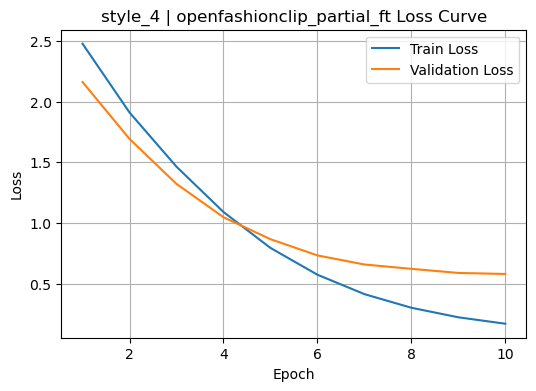

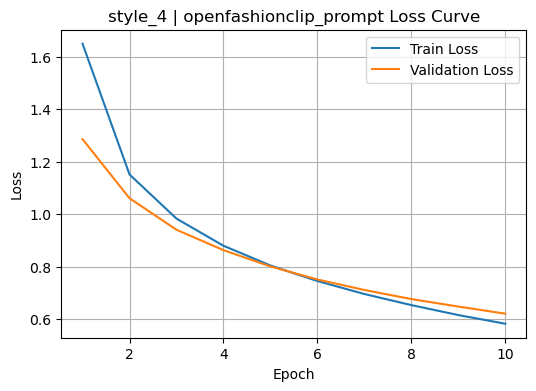

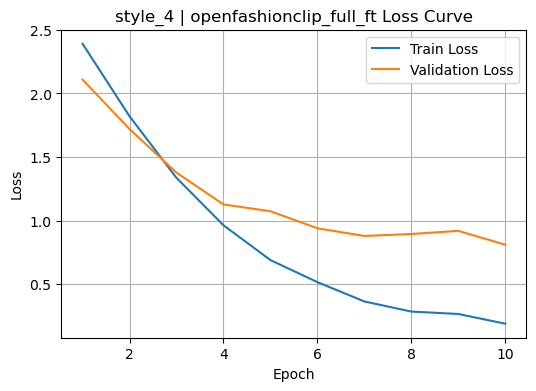

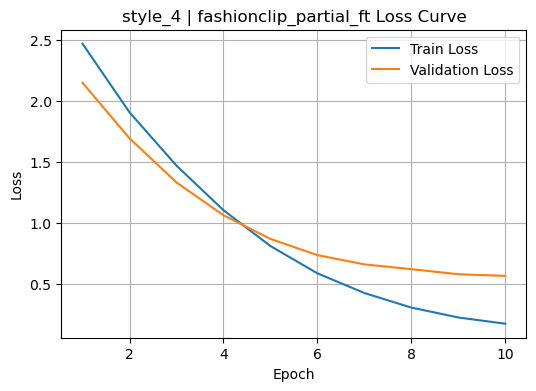

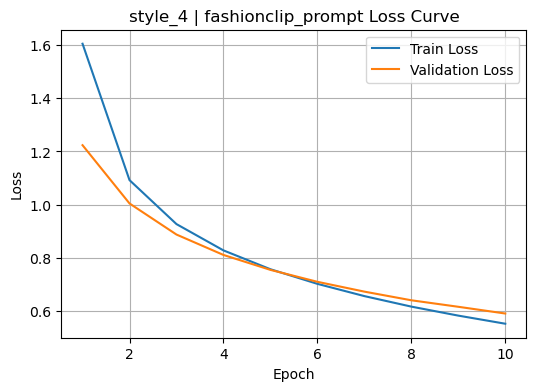

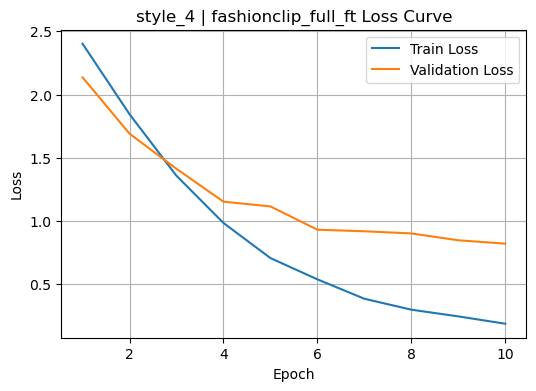

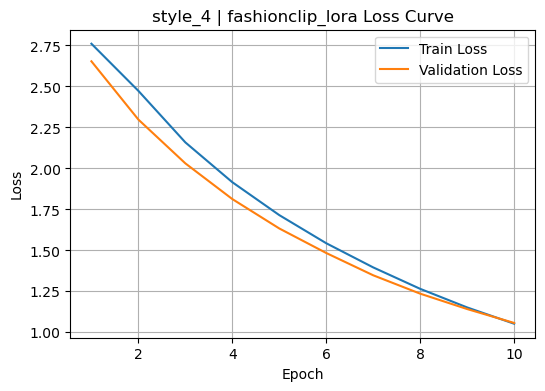


--- style_4 Overall Summary ---
                   Experiment  Macro F1  Accuracy  Macro Precision  \
0  openfashionclip_partial_ft  0.855065  0.854711         0.856076   
1      openfashionclip_prompt  0.842839  0.842043         0.844799   
2     openfashionclip_full_ft  0.793017  0.793745         0.796903   
3      fashionclip_partial_ft  0.861648  0.860649         0.863127   
4          fashionclip_prompt  0.838956  0.837688         0.840500   
5         fashionclip_full_ft  0.784568  0.781869         0.792919   
6            fashionclip_lora  0.734824  0.736738         0.744567   

   Macro Recall  
0      0.857097  
1      0.842853  
2      0.796680  
3      0.862790  
4      0.839669  
5      0.782774  
6      0.740407  
             style  openfashionclip_partial_ft  openfashionclip_prompt  \
0           Casual                    0.828947                0.827338   
1           Ethnic                    0.923588                0.932039   
2           Formal                    0.

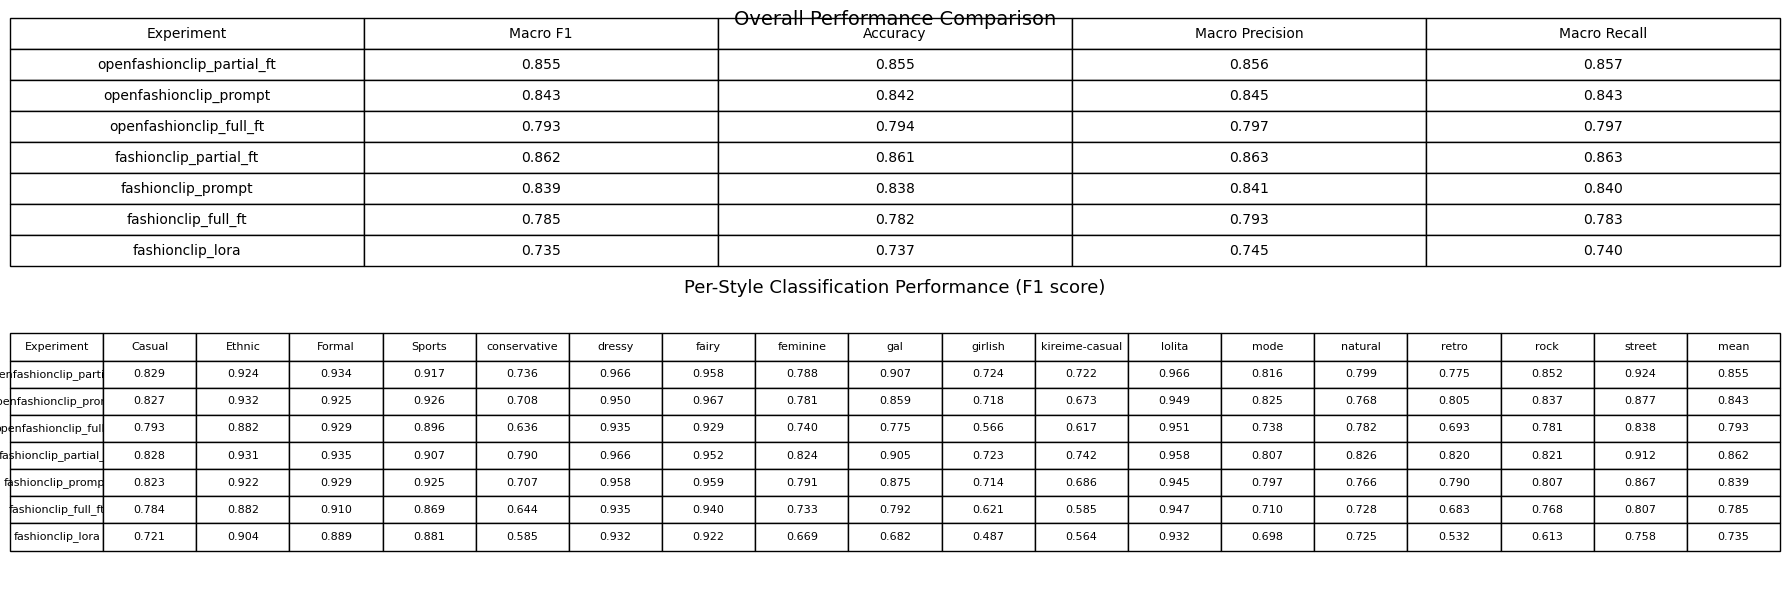

Saved: ft_result\style_4\summary\final_comparison_figure.png
                   experiment  \
0  openfashionclip_partial_ft   
1      openfashionclip_prompt   
2     openfashionclip_full_ft   
3      fashionclip_partial_ft   
4          fashionclip_prompt   
5         fashionclip_full_ft   
6            fashionclip_lora   

                                      best_ckpt_path  \
0  ft_result\style_4\openfashionclip_partial_ft\c...   
1  ft_result\style_4\openfashionclip_prompt\check...   
2  ft_result\style_4\openfashionclip_full_ft\chec...   
3  ft_result\style_4\fashionclip_partial_ft\check...   
4  ft_result\style_4\fashionclip_prompt\checkpoin...   
5  ft_result\style_4\fashionclip_full_ft\checkpoi...   
6  ft_result\style_4\fashionclip_lora\checkpoints...   

                                     prediction_path  
0  ft_result\style_4\openfashionclip_partial_ft\p...  
1  ft_result\style_4\openfashionclip_prompt\predi...  
2  ft_result\style_4\openfashionclip_full_ft\pred...  
3  ft

openfashionclip_partial_ft Train Epoch 1:   0%|          | 0/369 [00:00<?, ?it/s]

openfashionclip_partial_ft Val Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]


===== openfashionclip_partial_ft | Epoch 1/10 =====
Train Loss: 2.4903  |  Val Loss: 2.1735
Val Accuracy: 0.7806  |  Val Macro F1: 0.7778
Best checkpoint updated.


openfashionclip_partial_ft Train Epoch 2:   0%|          | 0/369 [00:00<?, ?it/s]

...


===== fashionclip_lora | Epoch 10/10 =====
Train Loss: 1.0453  |  Val Loss: 1.0461
Val Accuracy: 0.7525  |  Val Macro F1: 0.7483
Best checkpoint updated.

Saved history   : ft_result\style_5\fashionclip_lora\logs\training_history.csv
Saved checkpoint: ft_result\style_5\fashionclip_lora\checkpoints\best.pt


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Inference:   0%|          | 0/79 [00:00<?, ?it/s]

Saved predictions: ft_result\style_5\fashionclip_lora\predictions\test_predictions.csv

--- Training Loss Curves: style_5 ---


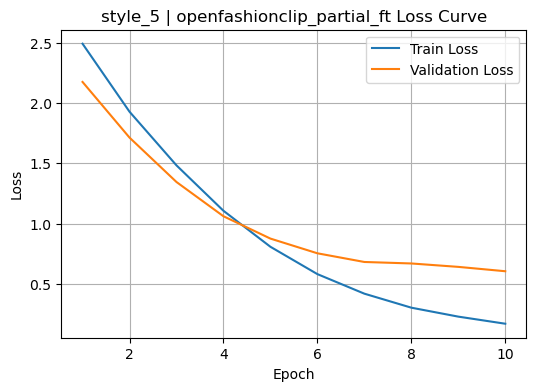

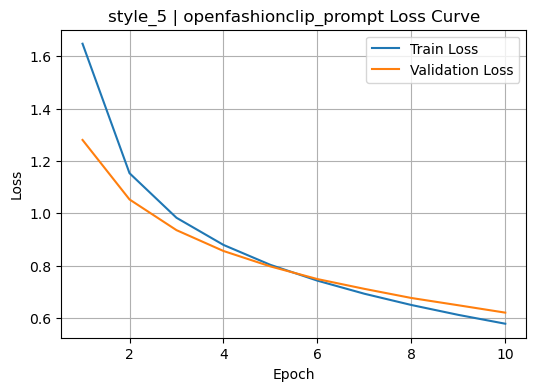

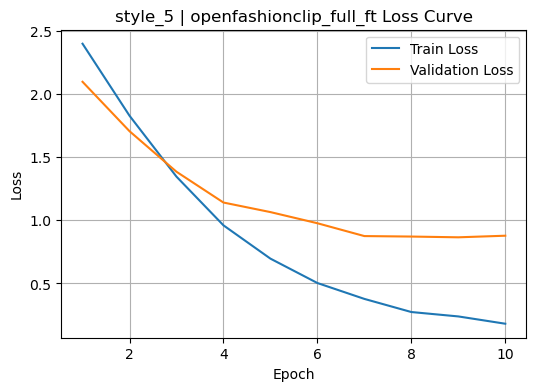

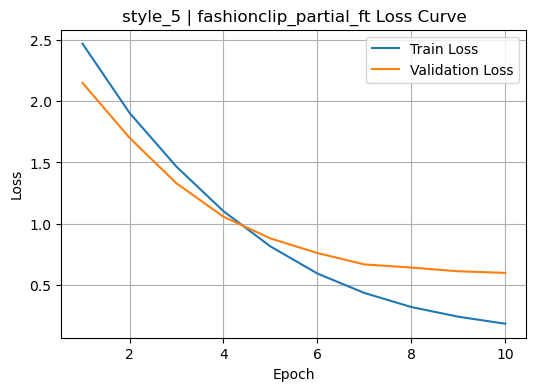

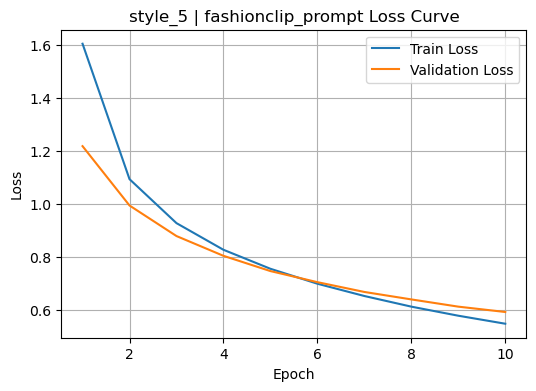

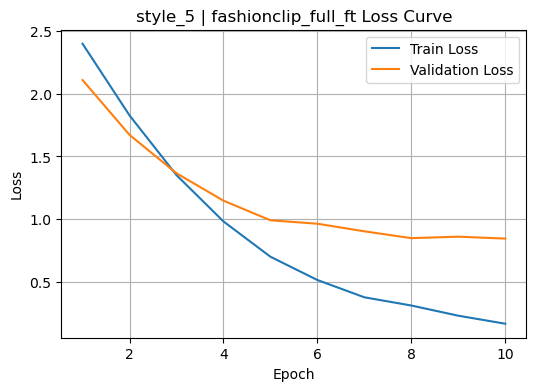

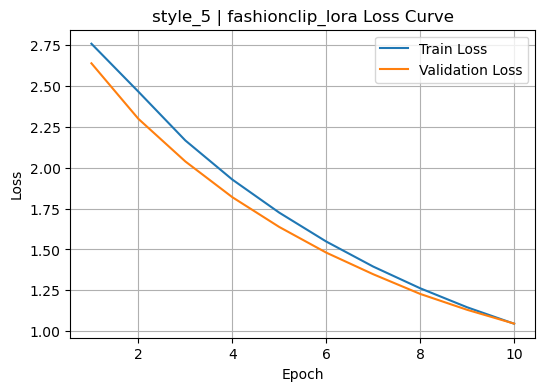


--- style_5 Overall Summary ---
                   Experiment  Macro F1  Accuracy  Macro Precision  \
0  openfashionclip_partial_ft  0.851659  0.851148         0.853359   
1      openfashionclip_prompt  0.834792  0.834521         0.837755   
2     openfashionclip_full_ft  0.765011  0.765637         0.774225   
3      fashionclip_partial_ft  0.849514  0.849565         0.853149   
4          fashionclip_prompt  0.837366  0.836500         0.840447   
5         fashionclip_full_ft  0.789004  0.788203         0.796178   
6            fashionclip_lora  0.737064  0.740697         0.741332   

   Macro Recall  
0      0.851186  
1      0.834678  
2      0.766298  
3      0.849023  
4      0.836571  
5      0.787882  
6      0.742704  
             style  openfashionclip_partial_ft  openfashionclip_prompt  \
0           Casual                    0.866894                0.830450   
1           Ethnic                    0.945946                0.921502   
2           Formal                    0.

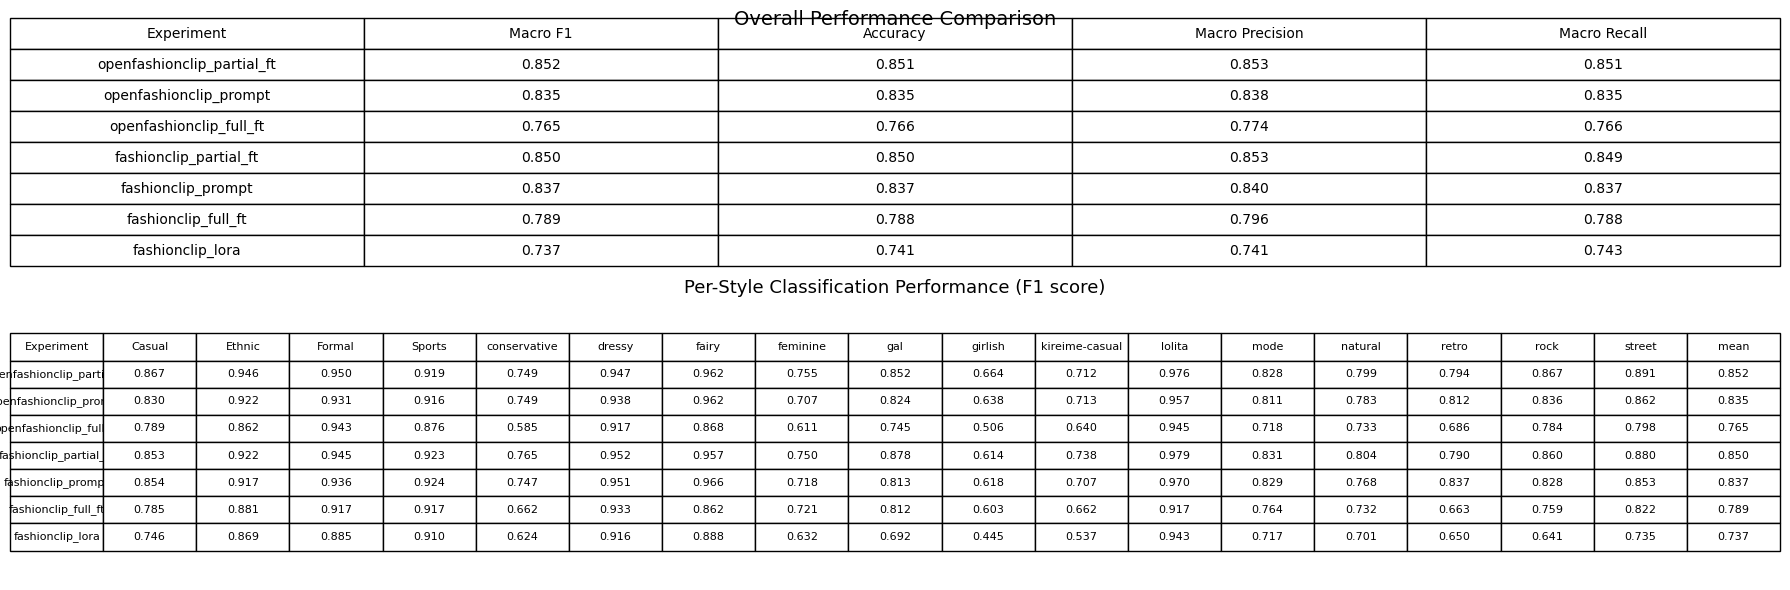

Saved: ft_result\style_5\summary\final_comparison_figure.png
                   experiment  \
0  openfashionclip_partial_ft   
1      openfashionclip_prompt   
2     openfashionclip_full_ft   
3      fashionclip_partial_ft   
4          fashionclip_prompt   
5         fashionclip_full_ft   
6            fashionclip_lora   

                                      best_ckpt_path  \
0  ft_result\style_5\openfashionclip_partial_ft\c...   
1  ft_result\style_5\openfashionclip_prompt\check...   
2  ft_result\style_5\openfashionclip_full_ft\chec...   
3  ft_result\style_5\fashionclip_partial_ft\check...   
4  ft_result\style_5\fashionclip_prompt\checkpoin...   
5  ft_result\style_5\fashionclip_full_ft\checkpoi...   
6  ft_result\style_5\fashionclip_lora\checkpoints...   

                                     prediction_path  
0  ft_result\style_5\openfashionclip_partial_ft\p...  
1  ft_result\style_5\openfashionclip_prompt\predi...  
2  ft_result\style_5\openfashionclip_full_ft\pred...  
3  ft

In [27]:
experiment_names = [
    "openfashionclip_partial_ft",
    "openfashionclip_prompt",
    "openfashionclip_full_ft",
    "fashionclip_partial_ft",
    "fashionclip_prompt",
    "fashionclip_full_ft",
    "fashionclip_lora"
]

# Collect all results across splits for final summary
ft_all_results = {}  # split_name -> list of experiment result dicts

for split_name in SPLIT_FOLDERS:
    print(f"\n{'='*60}")
    print(f"Fine-Tuning | Split: {split_name}")
    print(f"{'='*60}")

    # Set experiment root for this split (used by create_exp_dirs)
    EXP_ROOT = os.path.join("ft_result", split_name)
    os.makedirs(EXP_ROOT, exist_ok=True)

    # Load CSVs
    paths    = get_split_paths(split_name)
    train_df = pd.read_csv(paths["train_csv"])
    val_df   = pd.read_csv(paths["val_csv"])
    test_df  = pd.read_csv(paths["test_csv"])

    train_df["id"] = train_df["id"].astype(str)
    val_df["id"]   = val_df["id"].astype(str)
    test_df["id"]  = test_df["id"].astype(str)

    print("Train:", train_df.shape)
    print("Val:", val_df.shape)
    print("Test:", test_df.shape)

    style_names = sorted(train_df["style"].unique())
    label2idx   = {label: idx for idx, label in enumerate(style_names)}
    idx2label   = {idx: label for label, idx in label2idx.items()}
    num_classes = len(style_names)

    print("Classes:", num_classes)
    print(style_names)

    # Build image lookups
    train_lookup = build_image_lookup(paths["train_img_dir"])
    val_lookup   = build_image_lookup(paths["val_img_dir"])
    test_lookup  = build_image_lookup(paths["test_img_dir"])

    print("Train images:", len(train_lookup))
    print("Val images  :", len(val_lookup))
    print("Test images :", len(test_lookup))

    # Build datasets and dataloaders
    open_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, image_transform=openclip_preprocess)
    open_val_ds   = StyleImageDataset(val_df,   val_lookup,   label2idx, image_transform=openclip_preprocess)
    open_test_ds  = StyleImageDataset(test_df,  test_lookup,  label2idx, image_transform=openclip_preprocess)

    open_train_loader = DataLoader(open_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    open_val_loader   = DataLoader(open_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    open_test_loader  = DataLoader(open_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    fclip_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, image_transform=None)
    fclip_val_ds   = StyleImageDataset(val_df,   val_lookup,   label2idx, image_transform=None)
    fclip_test_ds  = StyleImageDataset(test_df,  test_lookup,  label2idx, image_transform=None)

    fclip_train_loader = DataLoader(fclip_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, collate_fn=fashionclip_collate_fn)
    fclip_val_loader   = DataLoader(fclip_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=fashionclip_collate_fn)
    fclip_test_loader  = DataLoader(fclip_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=fashionclip_collate_fn)

    # Run all experiments for this split
    all_results = []

    for exp_name in experiment_names:
        try:
            result = run_single_experiment(exp_name, num_classes, style_names)
            all_results.append(result)
        except Exception as e:
            print(f"Experiment failed: {exp_name}")
            print(str(e))

    # Training loss curves for this split
    print(f"\n--- Training Loss Curves: {split_name} ---")
    for exp in experiment_names:
        history_path = os.path.join(EXP_ROOT, exp, "logs", "training_history.csv")
        if not os.path.exists(history_path):
            print(f"Skip {exp}, training history not found")
            continue
        df = pd.read_csv(history_path)
        plt.figure(figsize=(6, 4))
        plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
        plt.plot(df["epoch"], df["val_loss"],   label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{split_name} | {exp} Loss Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Per-split summary
    summary_dir = os.path.join(EXP_ROOT, "summary")
    os.makedirs(summary_dir, exist_ok=True)

    overall_rows    = []
    per_style_merge = pd.DataFrame({"style": style_names})

    for result in all_results:
        exp_name = result["experiment"]
        row = result["overall_df"].iloc[0].to_dict()
        row["Experiment"] = exp_name
        overall_rows.append(row)

        style_df = result["per_style_df"][["style", "f1"]].rename(columns={"f1": exp_name})
        per_style_merge = per_style_merge.merge(style_df, on="style", how="left")

    overall_summary_df = pd.DataFrame(overall_rows)
    overall_summary_df = overall_summary_df[["Experiment", "Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]]
    overall_summary_df.to_csv(os.path.join(summary_dir, "overall_performance_comparison.csv"), index=False)
    per_style_merge.to_csv(os.path.join(summary_dir, "per_style_f1_comparison.csv"), index=False)

    print(f"\n--- {split_name} Overall Summary ---")
    print(overall_summary_df)
    print(per_style_merge)

    # Comparison figure for this split
    def draw_final_comparison_figure(overall_df, per_style_df, save_path):
        fig = plt.figure(figsize=(18, 6))
        gs  = fig.add_gridspec(2, 1, height_ratios=[1, 1.3])

        ax1 = fig.add_subplot(gs[0])
        ax1.axis("off")
        ax1.set_title("Overall Performance Comparison", fontsize=14, pad=8)

        show_overall = overall_df.copy()
        for col in ["Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]:
            show_overall[col] = show_overall[col].map(lambda x: f"{x:.3f}")

        table1 = ax1.table(
            cellText=show_overall.values, colLabels=show_overall.columns,
            cellLoc="center", loc="center"
        )
        table1.auto_set_font_size(False)
        table1.set_fontsize(10)
        table1.scale(1, 1.6)

        ax2 = fig.add_subplot(gs[1])
        ax2.axis("off")
        ax2.set_title("Per-Style Classification Performance (F1 score)", fontsize=13, pad=8)

        bottom_df = per_style_df.copy().T
        bottom_df.columns = bottom_df.iloc[0]
        bottom_df = bottom_df.iloc[1:].reset_index()
        bottom_df = bottom_df.rename(columns={"index": "Experiment"})

        style_cols = [c for c in bottom_df.columns if c != "Experiment"]
        bottom_df["mean"] = bottom_df[style_cols].astype(float).mean(axis=1)

        for col in bottom_df.columns:
            if col != "Experiment":
                bottom_df[col] = bottom_df[col].map(lambda x: f"{float(x):.3f}")

        table2 = ax2.table(
            cellText=bottom_df.values, colLabels=bottom_df.columns,
            cellLoc="center", loc="center"
        )
        table2.auto_set_font_size(False)
        table2.set_fontsize(8)
        table2.scale(1, 1.4)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

    final_fig_path = os.path.join(summary_dir, "final_comparison_figure.png")
    draw_final_comparison_figure(overall_summary_df, per_style_merge, final_fig_path)
    print("Saved:", final_fig_path)

    # Save experiment index for this split
    experiment_index = []
    for result in all_results:
        experiment_index.append({
            "experiment":      result["experiment"],
            "best_ckpt_path":  result["best_ckpt_path"],
            "prediction_path": result["prediction_path"]
        })
    experiment_index_df = pd.DataFrame(experiment_index)
    experiment_index_df.to_csv(os.path.join(summary_dir, "experiment_index.csv"), index=False)
    print(experiment_index_df)

    # Store results for cross-split summary
    ft_all_results[split_name] = all_results

## Fine-Tuning Summary: Mean and Std Across Splits

Fine-Tuning Summary (mean +/- std across 5 splits):
                                     Macro F1           Accuracy    Macro Precision       Macro Recall
Experiment                                                                                            
openfashionclip_partial_ft  0.8623 +/- 0.0076  0.8616 +/- 0.0075  0.8664 +/- 0.0073  0.8624 +/- 0.0067
openfashionclip_prompt      0.8493 +/- 0.0024  0.8484 +/- 0.0026  0.8521 +/- 0.0022  0.8493 +/- 0.0029
openfashionclip_full_ft     0.8033 +/- 0.0013  0.8003 +/- 0.0023  0.8099 +/- 0.0013  0.8022 +/- 0.0016
fashionclip_partial_ft      0.8627 +/- 0.0036  0.8620 +/- 0.0044  0.8649 +/- 0.0031  0.8623 +/- 0.0036
fashionclip_prompt          0.8496 +/- 0.0027  0.8484 +/- 0.0031  0.8510 +/- 0.0026  0.8497 +/- 0.0029
fashionclip_full_ft         0.7899 +/- 0.0128  0.7869 +/- 0.0132  0.8031 +/- 0.0093  0.7876 +/- 0.0142
fashionclip_lora            0.7499 +/- 0.0100  0.7516 +/- 0.0089  0.7535 +/- 0.0090  0.7540 +/- 0.0087

Saved: ft_result/sum

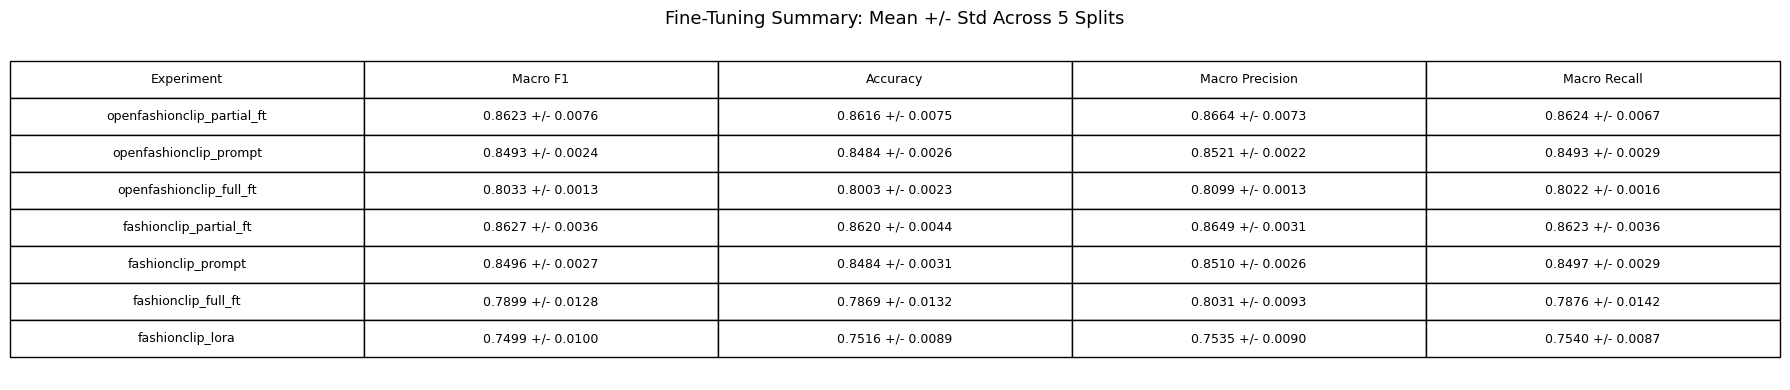

In [25]:
# Aggregate overall metrics across splits for each fine-tuning experiment
ft_metric_keys = ["Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]

# Collect per-experiment, per-split metrics
ft_collected = {exp: {k: [] for k in ft_metric_keys} for exp in experiment_names}

for split_name in SPLIT_FOLDERS:
    if split_name not in ft_all_results:
        continue
    for result in ft_all_results[split_name]:
        exp_name   = result["experiment"]
        overall_row = result["overall_df"].iloc[0].to_dict()
        for k in ft_metric_keys:
            if k in overall_row:
                ft_collected[exp_name][k].append(float(overall_row[k]))

ft_summary_rows = []

for exp_name in experiment_names:
    row = {"Experiment": exp_name}
    for k in ft_metric_keys:
        values = ft_collected[exp_name][k]
        if values:
            mean_val = np.mean(values)
            std_val  = np.std(values)
            row[k]   = f"{mean_val:.4f} +/- {std_val:.4f}"
        else:
            row[k] = "N/A"
    ft_summary_rows.append(row)

ft_summary_df = pd.DataFrame(ft_summary_rows).set_index("Experiment")

print("Fine-Tuning Summary (mean +/- std across 5 splits):")
print(ft_summary_df.to_string())

os.makedirs("ft_result/summary", exist_ok=True)
ft_summary_df.to_csv("ft_result/summary/ft_summary.csv")
print("\nSaved: ft_result/summary/ft_summary.csv")

# Display as figure
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis("off")
ax.set_title("Fine-Tuning Summary: Mean +/- Std Across 5 Splits", fontsize=13, pad=10)

display_df = ft_summary_df.reset_index()
table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.tight_layout()
plt.savefig("ft_result/summary/ft_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
import os
import pandas as pd

# Root directory
root_dir = "ft_result"

# Style folders
style_folders = [f"style_{i}" for i in range(1, 6)]

# File names
files = [
    "overall_performance_comparison.csv",
    "per_style_f1_comparison.csv"
]

def load_and_aggregate(file_name):
    dfs = []

    # Load all CSV files
    for folder in style_folders:
        path = os.path.join(root_dir, folder, "summary", file_name)
        df = pd.read_csv(path)
        dfs.append(df)

    # Concatenate all data
    combined_df = pd.concat(dfs, axis=0)

    # Identify numeric columns only
    numeric_cols = combined_df.select_dtypes(include="number").columns

    # Group by non-numeric columns (e.g., model or style)
    group_cols = [col for col in combined_df.columns if col not in numeric_cols]

    # Compute mean and std
    mean_df = combined_df.groupby(group_cols)[numeric_cols].mean()
    std_df = combined_df.groupby(group_cols)[numeric_cols].std()

    # Combine mean and std into one table
    result_df = mean_df.copy()
    for col in numeric_cols:
        result_df[col] = (
            mean_df[col].round(2).astype(str)
            + " ± "
            + std_df[col].round(2).astype(str)
        )

    return result_df.reset_index()

# Process both files
overall_result = load_and_aggregate("overall_performance_comparison.csv")
style_result = load_and_aggregate("per_style_f1_comparison.csv")

# Save results
overall_result.to_csv("overall_mean_std.csv", index=False)
style_result.to_csv("style_mean_std.csv", index=False)

print("Finished computing mean ± std")

print("\n=== Overall Performance (Mean ± Std) ===\n")
print(overall_result.to_string(index=False))

print("\n=== Per Style F1 (Mean ± Std) ===\n")
print(style_result.to_string(index=False))

Finished computing mean ± std

=== Overall Performance (Mean ± Std) ===

                Experiment    Macro F1    Accuracy Macro Precision Macro Recall
       fashionclip_full_ft 0.79 ± 0.01 0.79 ± 0.01      0.8 ± 0.01  0.79 ± 0.01
          fashionclip_lora 0.74 ± 0.01 0.75 ± 0.01     0.75 ± 0.01  0.75 ± 0.01
    fashionclip_partial_ft 0.86 ± 0.01 0.86 ± 0.01     0.86 ± 0.01  0.86 ± 0.01
        fashionclip_prompt 0.85 ± 0.01 0.84 ± 0.01     0.85 ± 0.01  0.85 ± 0.01
   openfashionclip_full_ft 0.79 ± 0.02 0.79 ± 0.02      0.8 ± 0.02  0.79 ± 0.02
openfashionclip_partial_ft 0.86 ± 0.01 0.86 ± 0.01     0.86 ± 0.01  0.86 ± 0.01
    openfashionclip_prompt 0.85 ± 0.01 0.84 ± 0.01     0.85 ± 0.01  0.85 ± 0.01

=== Per Style F1 (Mean ± Std) ===

         style openfashionclip_partial_ft openfashionclip_prompt openfashionclip_full_ft fashionclip_partial_ft fashionclip_prompt fashionclip_full_ft fashionclip_lora
        Casual                0.85 ± 0.02            0.83 ± 0.02              0.8 ±